`10_tracking_results.ipynb` analiza los resultados generados por `09_tracking.py`.

En este notebook se comparan los trackers ByteTrack y BoT-SORT utilizando el mejor detector YOLO
seleccionado previamente. Se evalúan dos escenarios:

1. `labels_track` como entrada al tracker, para aislar el comportamiento del tracker.
2. Detecciones del modelo YOLO como entrada al tracker, para evaluar el pipeline completo.

Las métricas se resumen por secuencia, de forma ponderada por número de objetos y finalmente se
compara ByteTrack vs BoT-SORT sobre el conjunto de test utilizando detecciones YOLO.

# Imports

In [295]:
import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from matplotlib.patches import Patch

# ==========================================
# PATH CONFIGURATION
# ==========================================
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from utils.file_utils import read_yaml

CONFIG_PATH = PROJECT_ROOT / "paths.yaml"
config = read_yaml(CONFIG_PATH)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /home/cgonzalez/Object_Recognition


# Configuración del experimento

Se selecciona el mejor modelo entrenado para la fase de detección como input para el tracking. En este caso se selecciona `yolo26m`, escenario `set2_balanced_full`, `fold 2`

In [296]:
SELECTED_MODEL = "yolo26m"
SELECTED_EXPERIMENT = "set2_balanced_full"
N_FOLD = 2
SELECTED_FOLD = f"fold_{N_FOLD}_config"

MODEL_RUN_DIR = PROJECT_ROOT / "runs" / SELECTED_MODEL / SELECTED_EXPERIMENT / SELECTED_FOLD
TRACKING_ROOT = MODEL_RUN_DIR / "tracking"

print("MODEL_RUN_DIR:", MODEL_RUN_DIR)
print("TRACKING_ROOT:", TRACKING_ROOT)

MODEL_RUN_DIR: /home/cgonzalez/Object_Recognition/runs/yolo26m/set2_balanced_full/fold_2_config
TRACKING_ROOT: /home/cgonzalez/Object_Recognition/runs/yolo26m/set2_balanced_full/fold_2_config/tracking


Se definen las carpetas donde se almacenarán las tablas en formato LaTeX y las figuras en formato `.png` y `.pdf` para el documento final.

In [297]:
DOCS_DIR = PROJECT_ROOT / "notebook_scripts" / "docs"
DOCS_IMAGES_DIR = DOCS_DIR / "images"
DOCS_LATEX_DIR = DOCS_DIR / "latex"

DOCS_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
DOCS_LATEX_DIR.mkdir(parents=True, exist_ok=True)

print("DOCS_IMAGES_DIR:", DOCS_IMAGES_DIR)
print("DOCS_LATEX_DIR:", DOCS_LATEX_DIR)

DOCS_IMAGES_DIR: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images
DOCS_LATEX_DIR: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex


# Trackers, particiones y entradas evaluadas

Se comparan dos trackers:

- ByteTrack
- BoT-SORT

Para cada tracker se evalúan tres particiones:

- train
- validation
- test

Y dos tipos de entrada:

- `labels_track`: etiquetas reales usadas como detecciones perfectas.
- `model_detections`: detecciones producidas por YOLO.

In [298]:
TRACKER_RUNS = {
    "bytetrack": "bytetrack_tracking",
    "botsort": "botsort_tracking",
}

SPLITS = [
    f"fold_{N_FOLD}_train",
    f"fold_{N_FOLD}_val",
    "test",
]

SOURCES = {
    "gt_label_detections": "GT labels as input",
    "model_detections": "YOLO detections as input",
}

SPLIT_NAMES = {
    f"fold_{N_FOLD}_train": "Train",
    f"fold_{N_FOLD}_val": "Val",
    "test": "Test",
}

TRACKER_NAMES = {
    "bytetrack": "ByteTrack",
    "botsort": "BoT-SORT",
}

SOURCE_NAMES = {
    "gt_label_detections": "GT labels",
    "model_detections": "YOLO detections",
}

# Métricas de tracking

Se seleccionan las métricas principales de evaluación MOT ([py-mometrics](https://github.com/cheind/py-motmetrics)). 

Las flechas indican si interesa maximizar o minimizar cada métrica:

- `IDF1`, `Recall`, `Precision` y `MOTA`: cuanto mayor, mejor.
- `MOTP`, falsos positivos, falsos negativos, cambios de identidad y fragmentaciones: cuanto menor, mejor

En esta sección se describen las métricas utilizadas para evaluar el rendimiento de los trackers ByteTrack y BoT-SORT. Las flechas indican si interesa maximizar o minimizar cada métrica.

| Métrica | Dirección | Descripción |
|---|---:|---|
| `num_frames` | — | Número total de frames evaluados en la secuencia. |
| `num_objects` | — | Número total de apariciones de objetos anotados a lo largo de todos los frames. |
| `idf1` | ↑ | Mide el equilibrio entre precisión y recall de identidad usando una asignación global entre trayectorias reales y predichas. |
| `idp` | ↑ | Mide la precisión de identidad, es decir, qué proporción de las identidades predichas corresponden correctamente a identidades reales. |
| `idr` | ↑ | Mide el recall de identidad, es decir, qué proporción de las identidades reales han sido correctamente recuperadas por el tracker. |
| `recall` | ↑ | Mide la proporción de objetos reales que han sido detectados o asociados correctamente. |
| `precision` | ↑ | Mide la proporción de predicciones del tracker que corresponden realmente a objetos anotados. |
| `mostly_tracked` | ↑ | Número de objetos que han sido seguidos correctamente durante al menos el 80% de su duración en la secuencia. |
| `partially_tracked` | — | Número de objetos seguidos entre el 20% y el 80% de su duración en la secuencia. |
| `mostly_lost` | ↓ | Número de objetos que han sido seguidos durante menos del 20% de su duración en la secuencia. |
| `num_false_positives` | ↓ | Número total de predicciones generadas por el tracker que no corresponden a ningún objeto real. |
| `num_misses` | ↓ | Número total de objetos reales que no han sido detectados o asociados por el tracker. |
| `num_switches` | ↓ | Número total de cambios de identidad, es decir, veces que un objeto real pasa a estar asociado a otro ID predicho. |
| `num_fragmentations` | ↓ | Número total de fragmentaciones de trayectoria, cuando un objeto pasa de estar seguido a no estar seguido y después vuelve a ser recuperado. |
| `mota` | ↑ | Resume la precisión global del tracker penalizando falsos positivos, falsos negativos y cambios de identidad. |
| `motp` | ↓ | Mide el error medio de localización entre las cajas predichas y las cajas reales asociadas. |

Métricas derivadas usadas en los resúmenes ponderados

| Métrica derivada | Dirección | Descripción |
|---|---:|---|
| `MT/obj` | ↑ | Proporción de objetos mayoritariamente seguidos respecto al número total de objetos evaluados. |
| `PT/obj` | — | Proporción de objetos parcialmente seguidos respecto al número total de objetos evaluados. |
| `ML/obj` | ↓ | Proporción de objetos mayoritariamente perdidos respecto al número total de objetos evaluados. |
| `FP/obj` | ↓ | Número medio de falsos positivos por objeto anotado. |
| `FN/obj` | ↓ | Número medio de objetos perdidos por objeto anotado. |
| `IDs/obj` | ↓ | Número medio de cambios de identidad por objeto anotado. |
| `FM/obj` | ↓ | Número medio de fragmentaciones por objeto anotado. |

In [299]:
METRIC_INFO = {
    # Informative metrics
    "num_frames": {
        "label": "Frames",
        "latex": "Frames",
        "higher_is_better": None,
        "type": "info",
    },
    "num_objects": {
        "label": "Objects",
        "latex": "Objects",
        "higher_is_better": None,
        "type": "info",
    },

    # ID metrics
    "idf1": {
        "label": "IDF1 ↑",
        "latex": r"IDF1 $\uparrow$",
        "higher_is_better": True,
        "type": "score",
    },
    "idp": {
        "label": "IDP ↑",
        "latex": r"IDP $\uparrow$",
        "higher_is_better": True,
        "type": "score",
    },
    "idr": {
        "label": "IDR ↑",
        "latex": r"IDR $\uparrow$",
        "higher_is_better": True,
        "type": "score",
    },

    # Detection / association metrics
    "recall": {
        "label": "Recall ↑",
        "latex": r"Recall $\uparrow$",
        "higher_is_better": True,
        "type": "score",
    },
    "precision": {
        "label": "Precision ↑",
        "latex": r"Precision $\uparrow$",
        "higher_is_better": True,
        "type": "score",
    },

    # Track coverage metrics
    "mostly_tracked": {
        "label": "MT ↑",
        "latex": r"MT $\uparrow$",
        "higher_is_better": True,
        "type": "count",
    },
    "partially_tracked": {
        "label": "PT",
        "latex": "PT",
        "higher_is_better": None,
        "type": "count",
    },
    "mostly_lost": {
        "label": "ML ↓",
        "latex": r"ML $\downarrow$",
        "higher_is_better": False,
        "type": "count",
    },

    # Error counts
    "num_false_positives": {
        "label": "FP ↓",
        "latex": r"FP $\downarrow$",
        "higher_is_better": False,
        "type": "count",
    },
    "num_misses": {
        "label": "FN ↓",
        "latex": r"FN $\downarrow$",
        "higher_is_better": False,
        "type": "count",
    },
    "num_switches": {
        "label": "IDs ↓",
        "latex": r"IDs $\downarrow$",
        "higher_is_better": False,
        "type": "count",
    },
    "num_fragmentations": {
        "label": "FM ↓",
        "latex": r"FM $\downarrow$",
        "higher_is_better": False,
        "type": "count",
    },

    # Global MOT metrics
    "mota": {
        "label": "MOTA ↑",
        "latex": r"MOTA $\uparrow$",
        "higher_is_better": True,
        "type": "score",
    },
    "motp": {
        "label": "MOTP ↓",
        "latex": r"MOTP $\downarrow$",
        "higher_is_better": False,
        "type": "score",
    },
    
    # Timing metrics
    "tiempo_detector/frame": {
        "label": "Detector/frame (s) ↓",
        "latex": r"Detector/frame (s) $\downarrow$",
        "higher_is_better": False,
        "type": "time",
    },
    "tiempo_tracker/frame": {
        "label": "Tracker/frame (s) ↓",
        "latex": r"Tracker/frame (s) $\downarrow$",
        "higher_is_better": False,
        "type": "time",
    },
}

# METRIC GROUPS
INFO_METRICS = [
    "num_frames",
    "num_objects",
]

MAIN_SCORE_METRICS = [
    "idf1",
    "idp",
    "idr",
    "recall",
    "precision",
    "mota",
    "motp",
]

TRACK_COVERAGE_METRICS = [
    "mostly_tracked",
    "partially_tracked",
    "mostly_lost",
]

ERROR_COUNT_METRICS = [
    "num_false_positives",
    "num_misses",
    "num_switches",
    "num_fragmentations",
]

MAIN_COUNT_METRICS = TRACK_COVERAGE_METRICS + ERROR_COUNT_METRICS

MAIN_METRICS = (
    INFO_METRICS
    + MAIN_SCORE_METRICS
    + MAIN_COUNT_METRICS
)

PLOT_METRICS_COMMON = [
    "IDF1 ↑",
    "IDP ↑",
    "IDR ↑",
    "Recall ↑",
    "Precision ↑",
    "MOTA ↑",
    "MOTP ↓",
    "MT/obj ↑",
    "PT/obj",
    "ML/obj ↓",
    "IDs/obj ↓",
]

PLOT_METRICS = PLOT_METRICS_COMMON.copy()
FINAL_PLOT_METRICS = PLOT_METRICS_COMMON.copy()
CLASS_PLOT_METRICS = PLOT_METRICS_COMMON.copy()

TABLE_METRICS = [
    "IDF1 ↑",
    "IDP ↑",
    "IDR ↑",
    "Recall ↑",
    "Precision ↑",
    "MOTA ↑",
    "MOTP ↓",
    "MT/obj ↑",
    "PT/obj",
    "ML/obj ↓",
    "FP/obj ↓",
    "FN/obj ↓",
    "IDs/obj ↓",
    "FM/obj ↓",
]

# Funciones auxiliares

Estas funciones se encargan de:
- Localizar los archivos `metrics.csv` generados por `09_tracking.py`.
- Cargar todos los resultados en un único DataFrame.
- Formatear columnas con flechas.
- Generar resúmenes ponderados por número de objetos.
- Exportar tablas LaTeX.
- Guardar figuras en `.png` y `.pdf`.

In [300]:
def get_metrics_path(
    tracker: str,
    split: str,
    source: str,
) -> Path:
    """
    Builds the metrics path generated by 09_tracking.py.

    Args:
        tracker (str): Tracker name. Example: 'bytetrack' or 'botsort'.
        split (str): Split name. Example: 'fold_2_train', 'fold_2_val', 'test'.
        source (str): Source name. Either 'gt_label_detections' or 'model_detections'.

    Returns:
        Path: Metrics CSV path.
    """
    run_name = TRACKER_RUNS[tracker]
    split_dir = TRACKING_ROOT / run_name / split

    if source == "gt_label_detections":
        return (
            split_dir
            / "01_tracking_gt_label_detections"
            / tracker
            / "all_sequences"
            / "metrics_tracking_gt_all_sequences.csv"
        )

    if source == "model_detections":
        return (
            split_dir
            / "02_model_detections"
            / tracker
            / "all_sequences"
            / "metrics_tracking_model_detections_all_sequences.csv"
        )

    raise ValueError(f"Unknown source: {source}")

In [301]:
def load_all_results() -> pd.DataFrame:
    """
    Loads all available tracking metrics into a long dataframe.

    Returns:
        pd.DataFrame: Long dataframe with one row per tracker/split/source/sequence.
    """
    rows = []

    for tracker in TRACKER_RUNS:
        for split in SPLITS:
            for source in SOURCES:
                metrics_path = get_metrics_path(
                    tracker=tracker,
                    split=split,
                    source=source,
                )

                if not metrics_path.exists():
                    print(f"⚠️ Missing: {metrics_path}")
                    continue

                df = pd.read_csv(metrics_path, index_col=0)
                df = df.copy()

                df["tracker"] = tracker
                df["split"] = split
                df["source"] = source
                df["sequence"] = df.index

                rows.append(df.reset_index(drop=True))

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, axis=0).reset_index(drop=True)

In [302]:
def format_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Renames metric columns using readable labels with arrows.

    Args:
        df (pd.DataFrame): Metrics dataframe.

    Returns:
        pd.DataFrame: Dataframe with readable metric names.
    """
    rename_map = {
        metric: info["label"]
        for metric, info in METRIC_INFO.items()
        if metric in df.columns
    }

    return df.rename(columns=rename_map)

In [303]:
def sequence_register_table(
    all_results: pd.DataFrame,
    tracker: str,
    split: str,
    source: str,
) -> pd.DataFrame:
    """
    Creates a compact per-sequence table for visual inspection.

    Args:
        all_results (pd.DataFrame): Long tracking metrics dataframe.
        tracker (str): Tracker name.
        split (str): Split name.
        source (str): Source name.

    Returns:
        pd.DataFrame: Compact table indexed by sequence.
    """
    sub = all_results[
        (all_results["tracker"] == tracker)
        & (all_results["split"] == split)
        & (all_results["source"] == source)
    ].copy()

    if sub.empty:
        return pd.DataFrame()

    cols = [
        col for col in dict.fromkeys(["sequence"] + MAIN_METRICS)
        if col in sub.columns
    ]

    table = sub[cols].set_index("sequence")
    table = format_metric_columns(table)

    return table

In [304]:
def save_latex_table(
    df: pd.DataFrame,
    file_path: Path,
    caption: str,
    label: str,
    index: bool = False,
    float_format: str = "{:.3f}",
) -> None:
    """
    Saves a dataframe as a LaTeX table using booktabs style.

    Args:
        df (pd.DataFrame): Dataframe to export.
        file_path (Path): Output .tex file.
        caption (str): LaTeX table caption.
        label (str): LaTeX table label.
        index (bool): Whether to include the dataframe index.
        float_format (str): Format used for floating point values.

    Returns:
        None
    """
    file_path = Path(file_path)
    file_path.parent.mkdir(parents=True, exist_ok=True)

    latex_df = df.copy()

    latex_col_map = {}

    for metric, info in METRIC_INFO.items():
        if info["label"] in latex_df.columns:
            latex_col_map[info["label"]] = info["latex"]

    extra_latex_map = {
        "MT/obj ↑": r"MT/obj $\uparrow$",
        "PT/obj": "PT/obj",
        "ML/obj ↓": r"ML/obj $\downarrow$",
        "FP/obj ↓": r"FP/obj $\downarrow$",
        "FN/obj ↓": r"FN/obj $\downarrow$",
        "IDs/obj ↓": r"IDs/obj $\downarrow$",
        "FM/obj ↓": r"FM/obj $\downarrow$",
        "Frames": "Frames",
        "Objects": "Objects",
        "Detector/frame (s) ↓": r"Detector/frame (s) $\downarrow$",
        "Tracker/frame (s) ↓": r"Tracker/frame (s) $\downarrow$",
        "Detector/frame (ms) ↓": r"Detector/frame (ms) $\downarrow$",
        "Tracker/frame (ms) ↓": r"Tracker/frame (ms) $\downarrow$",
        "Total/frame (ms) ↓": r"Total/frame (ms) $\downarrow$",        
    }

    latex_col_map.update({
        key: value
        for key, value in extra_latex_map.items()
        if key in latex_df.columns
    })

    latex_df = latex_df.rename(columns=latex_col_map)

    latex_code = latex_df.to_latex(
        index=index,
        caption=caption,
        label=label,
        escape=False,
        float_format=lambda x: float_format.format(x),
        bold_rows=True,
        longtable=False,
    )

    with open(file_path, "w", encoding="utf-8") as f:
        f.write(latex_code)

    print(f"✅ Tabla LaTeX guardada en: {file_path}")

In [305]:
def save_current_figure(
    file_stem: str,
    output_dir: Path = DOCS_IMAGES_DIR,
) -> None:
    """
    Saves the current matplotlib figure as PNG and PDF.

    Args:
        file_stem (str): Output filename without extension.
        output_dir (Path): Output directory.

    Returns:
        None
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    png_path = output_dir / f"{file_stem}.png"
    pdf_path = output_dir / f"{file_stem}.pdf"

    plt.savefig(png_path, dpi=180, bbox_inches="tight")
    plt.savefig(pdf_path, format="pdf", dpi=180, bbox_inches="tight")

    print(f"✅ Figura guardada en: {png_path}")
    print(f"✅ Figura guardada en: {pdf_path}")

# Funciones de resumen

Las métricas tipo score se ponderan por el número de objetos, mientras que las métricas de conteo se transforman a ratios por objeto.

In [330]:
def weighted_summary_by_group(
    df: pd.DataFrame,
    group_cols: list,
) -> pd.DataFrame:
    """
    Computes a compact weighted summary.

    Score metrics are weighted by num_objects.
    Count metrics are converted to count / num_objects.

    Args:
        df (pd.DataFrame): Long metrics dataframe.
        group_cols (list): Columns used for grouping.

    Returns:
        pd.DataFrame: Compact summary dataframe.
    """
    rows = []

    for group_values, group_df in df.groupby(group_cols):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        row = {
            col: value
            for col, value in zip(group_cols, group_values)
        }

        weights = group_df["num_objects"].astype(float)
        valid_weights = weights > 0

        total_objects = group_df["num_objects"].sum()
        row["num_objects"] = total_objects
        
        total_frames = group_df["num_frames"].sum()
        row["num_frames"] = total_frames

        for metric in MAIN_SCORE_METRICS:
            if metric not in group_df.columns:
                continue

            values = group_df.loc[valid_weights, metric].astype(float)
            metric_weights = weights.loc[valid_weights]

            if len(values) == 0 or metric_weights.sum() == 0:
                row[METRIC_INFO[metric]["label"]] = np.nan
            else:
                row[METRIC_INFO[metric]["label"]] = np.average(
                    values,
                    weights=metric_weights,
                )

        count_labels = {
            "mostly_tracked": "MT/obj ↑",
            "partially_tracked": "PT/obj",
            "mostly_lost": "ML/obj ↓",
            "num_false_positives": "FP/obj ↓",
            "num_misses": "FN/obj ↓",
            "num_switches": "IDs/obj ↓",
            "num_fragmentations": "FM/obj ↓",
        }

        for metric, label in count_labels.items():
            if metric not in group_df.columns:
                continue

            if total_objects > 0:
                row[label] = group_df[metric].sum() / total_objects
            else:
                row[label] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [331]:
def weighted_time_summary_by_group(
    df: pd.DataFrame,
    group_cols: list,
) -> pd.DataFrame:
    """
    Computes weighted timing summary by group.

    Timing metrics are weighted by the number of frames in each sequence.

    Args:
        df (pd.DataFrame): Long tracking metrics dataframe.
        group_cols (list): Columns used for grouping.

    Returns:
        pd.DataFrame: Timing summary with detector, tracker and total time per frame.
    """
    required_cols = [
        "num_frames",
        "tiempo_detector/frame",
        "tiempo_tracker/frame",
    ]

    missing_cols = [
        col for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise ValueError(f"Missing timing columns: {missing_cols}")

    rows = []

    for group_values, group_df in df.groupby(group_cols):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        row = {
            col: value
            for col, value in zip(group_cols, group_values)
        }

        weights = group_df["num_frames"].astype(float)
        valid_weights = weights > 0

        row["num_sequences"] = len(group_df)
        row["num_frames"] = group_df["num_frames"].sum()

        detector_values = group_df.loc[valid_weights, "tiempo_detector/frame"].astype(float)
        tracker_values = group_df.loc[valid_weights, "tiempo_tracker/frame"].astype(float)
        time_weights = weights.loc[valid_weights]

        if len(detector_values) == 0 or time_weights.sum() == 0:
            detector_s = np.nan
            tracker_s = np.nan
        else:
            detector_s = np.average(detector_values, weights=time_weights)
            tracker_s = np.average(tracker_values, weights=time_weights)

        row["Detector/frame (s) ↓"] = detector_s
        row["Tracker/frame (s) ↓"] = tracker_s
        row["Total/frame (s) ↓"] = detector_s + tracker_s

        row["Detector/frame (ms) ↓"] = detector_s * 1000
        row["Tracker/frame (ms) ↓"] = tracker_s * 1000
        row["Total/frame (ms) ↓"] = (detector_s + tracker_s) * 1000

        rows.append(row)

    return pd.DataFrame(rows)

# Carga de los resultados

Cargamos todos los resultados generados en el script anterior (`09_tracking.py`)

In [332]:
all_results = load_all_results()

display(all_results.head())

print("Rows:", len(all_results))
print("Trackers:", sorted(all_results["tracker"].unique()))
print("Splits:", sorted(all_results["split"].unique()))
print("Sources:", sorted(all_results["source"].unique()))

,num_frames,idf1,idp,idr,recall,precision,num_objects,mostly_tracked,partially_tracked,mostly_lost,...,num_switches,num_fragmentations,mota,motp,tiempo_detector/frame,tiempo_tracker/frame,tracker,split,source,sequence
0,62,0.391203,0.428718,0.359725,0.836489,0.996923,1162,22,15,0,...,208,136,0.654905,0.126760,0.0,0.002268,bytetrack,fold_2_train,gt_label_detections,horse_2
1,286,0.585129,0.624020,0.550802,0.879836,0.996793,3179,54,13,0,...,412,281,0.747405,0.138425,0.0,0.001420,bytetrack,fold_2_train,gt_label_detections,horse_3
2,41,0.952575,0.959072,0.946164,0.986541,1.000000,743,19,1,0,...,7,7,0.977120,0.096561,0.0,0.001136,bytetrack,fold_2_train,gt_label_detections,horse_4
3,65,0.929425,0.942297,0.916901,0.972487,0.999423,1781,33,3,2,...,35,31,0.952274,0.076142,0.0,0.001659,bytetrack,fold_2_train,gt_label_detections,penguin_2
4,65,0.860852,0.870386,0.851525,0.977528,0.999180,1246,22,0,0,...,23,23,0.958266,0.090883,0.0,0.001198,bytetrack,fold_2_train,gt_label_detections,penguin_4


Rows: 68
Trackers: ['botsort', 'bytetrack']
Splits: ['fold_2_train', 'fold_2_val', 'test']
Sources: ['gt_label_detections', 'model_detections']


In [333]:
all_results_export = all_results.copy()

all_results_export["Tracker"] = all_results_export["tracker"].map(TRACKER_NAMES)
all_results_export["Split"] = all_results_export["split"].map(SPLIT_NAMES)
all_results_export["Entrada"] = all_results_export["source"].map(SOURCE_NAMES)
all_results_export["Secuencia"] = all_results_export["sequence"]

tracking_cols = [
    "Tracker",
    "Split",
    "Entrada",
    "Secuencia",
    "num_frames",
    "num_objects",
    "idf1",
    "idp",
    "idr",
    "recall",
    "precision",
    "mostly_tracked",
    "partially_tracked",
    "mostly_lost",
    "num_false_positives",
    "num_misses",
    "num_switches",
    "num_fragmentations",
    "mota",
    "motp",
    "tiempo_detector/frame",
    "tiempo_tracker/frame",
]

tracking_cols = [
    col for col in tracking_cols
    if col in all_results_export.columns
]

all_results_latex = all_results_export[tracking_cols].copy()
all_results_latex = format_metric_columns(all_results_latex)

# save_latex_table(
#     df=all_results_latex,
#     file_path=DOCS_LATEX_DIR / "tracking_all_results_long.tex",
#     caption="Resultados de tracking por secuencia para ByteTrack y BoT-SORT.",
#     label="tab:tracking_all_results_long",
#     index=False,
# )

display(all_results_latex.head())

,Tracker,Split,Entrada,Secuencia,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,...,PT,ML ↓,FP ↓,FN ↓,IDs ↓,FM ↓,MOTA ↑,MOTP ↓,Detector/frame (s) ↓,Tracker/frame (s) ↓
0,ByteTrack,Train,GT labels,horse_2,62,1162,0.391203,0.428718,0.359725,0.836489,...,15,0,3,190,208,136,0.654905,0.126760,0.0,0.002268
1,ByteTrack,Train,GT labels,horse_3,286,3179,0.585129,0.624020,0.550802,0.879836,...,13,0,9,382,412,281,0.747405,0.138425,0.0,0.001420
2,ByteTrack,Train,GT labels,horse_4,41,743,0.952575,0.959072,0.946164,0.986541,...,1,0,0,10,7,7,0.977120,0.096561,0.0,0.001136
3,ByteTrack,Train,GT labels,penguin_2,65,1781,0.929425,0.942297,0.916901,0.972487,...,3,2,1,49,35,31,0.952274,0.076142,0.0,0.001659
4,ByteTrack,Train,GT labels,penguin_4,65,1246,0.860852,0.870386,0.851525,0.977528,...,0,0,1,28,23,23,0.958266,0.090883,0.0,0.001198


# Registro por secuencia

Esta sección permite revisar manualmente el comportamiento de cada tracker en cada secuencia. Las flechas indican si la métrica debe maximizarse o minimizarse.

In [334]:
per_sequence_tables = []

for tracker in TRACKER_RUNS:
    for split in SPLITS:
        for source in SOURCES:
            table = sequence_register_table(
                all_results=all_results,
                tracker=tracker,
                split=split,
                source=source,
            )

            if table.empty:
                continue

            table_to_store = table.copy()
            table_to_store.insert(0, "Tracker", TRACKER_NAMES[tracker])
            table_to_store.insert(1, "Split", SPLIT_NAMES[split])
            table_to_store.insert(2, "Entrada", SOURCE_NAMES[source])
            table_to_store.insert(3, "Secuencia", table_to_store.index)

            per_sequence_tables.append(table_to_store.reset_index(drop=True))

            print("\n" + "=" * 100)
            print(
                f"Tracker: {TRACKER_NAMES[tracker]} | "
                f"Split: {SPLIT_NAMES[split]} | "
                f"Entrada: {SOURCE_NAMES[source]}"
            )
            print("=" * 100)

            display(table.style.format(
                precision=3,
                na_rep="-"))

per_sequence_results = pd.concat(
    per_sequence_tables,
    axis=0,
).reset_index(drop=True)

save_latex_table(
    df=per_sequence_results,
    file_path=DOCS_LATEX_DIR / "tracking_per_sequence_metrics.tex",
    caption="Métricas de tracking por secuencia.",
    label="tab:tracking_per_sequence_metrics",
    index=False,
)

display(
    per_sequence_results
    .head()
    .style.format(
        precision=3,
        na_rep="-"
    )
)


Tracker: ByteTrack | Split: Train | Entrada: GT labels


,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT ↑,PT,ML ↓,FP ↓,FN ↓,IDs ↓,FM ↓
sequence,,,,,,,,,,,,,,,,
horse_2,62,1162,0.391,0.429,0.360,0.836,0.997,0.655,0.127,22,15,0,3,190,208,136
horse_3,286,3179,0.585,0.624,0.551,0.880,0.997,0.747,0.138,54,13,0,9,382,412,281
horse_4,41,743,0.953,0.959,0.946,0.987,1.000,0.977,0.097,19,1,0,0,10,7,7
penguin_2,65,1781,0.929,0.942,0.917,0.972,0.999,0.952,0.076,33,3,2,1,49,35,31
penguin_4,65,1246,0.861,0.870,0.852,0.978,0.999,0.958,0.091,22,0,0,1,28,23,23
penguin_5,64,749,0.795,0.823,0.769,0.935,1.000,0.869,0.107,16,1,0,0,49,49,36
pig_2,62,2155,0.769,0.790,0.750,0.949,1.000,0.907,0.115,50,5,2,0,109,92,80
pig_3,62,1344,0.866,0.874,0.859,0.982,1.000,0.967,0.098,24,0,0,0,24,20,21
pig_4,54,1298,0.861,0.893,0.831,0.930,1.000,0.868,0.101,28,1,0,0,91,80,77



Tracker: ByteTrack | Split: Train | Entrada: YOLO detections


,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT ↑,PT,ML ↓,FP ↓,FN ↓,IDs ↓,FM ↓
sequence,,,,,,,,,,,,,,,,
horse_2,62,1162,0.245,0.414,0.174,0.420,1.000,0.309,0.133,1,24,12,0,674,129,136
horse_3,286,3179,0.402,0.592,0.304,0.512,0.998,0.411,0.136,6,47,14,4,1552,316,317
horse_4,41,743,0.444,0.601,0.353,0.587,1.000,0.529,0.111,1,17,2,0,307,43,69
penguin_2,65,1781,0.673,0.895,0.539,0.601,0.997,0.573,0.098,10,21,7,3,711,46,89
penguin_4,65,1246,0.527,0.874,0.377,0.431,0.998,0.421,0.100,4,9,9,1,709,12,46
penguin_5,64,749,0.529,0.812,0.393,0.483,1.000,0.447,0.130,4,4,9,0,387,27,33
pig_2,62,2155,0.481,0.678,0.373,0.548,0.997,0.502,0.137,9,37,11,3,973,97,139
pig_3,62,1344,0.587,0.728,0.491,0.673,0.998,0.640,0.120,7,17,0,2,440,42,92
pig_4,54,1298,0.740,0.856,0.652,0.760,0.999,0.680,0.132,16,13,0,1,311,104,123



Tracker: ByteTrack | Split: Val | Entrada: GT labels


...

,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT ↑,PT,ML ↓,FP ↓,FN ↓,IDs ↓,FM ↓
sequence,,,,,,,,,,,,,,,,
horse_7,263,2014,0.746,0.748,0.743,0.993,0.999,0.988,0.043,19,0,0,2,14,8,6
penguin_6,46,793,0.955,0.959,0.951,0.990,0.999,0.975,0.053,21,0,0,1,8,11,6
pig_5,63,1085,0.861,0.864,0.858,0.993,1.000,0.982,0.053,23,0,0,0,8,12,4



Tracker: BoT-SORT | Split: Test | Entrada: YOLO detections


,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT ↑,PT,ML ↓,FP ↓,FN ↓,IDs ↓,FM ↓
sequence,,,,,,,,,,,,,,,,
horse_7,263,2014,0.588,0.822,0.457,0.555,0.997,0.544,0.111,4,14,1,3,896,19,136
penguin_6,46,793,0.802,0.958,0.690,0.719,0.998,0.711,0.130,12,7,2,1,223,5,38
pig_5,63,1085,0.550,0.845,0.407,0.478,0.992,0.455,0.179,4,13,6,4,566,21,55


✅ Tabla LaTeX guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex/tracking_per_sequence_metrics.tex


,Tracker,Split,Entrada,Secuencia,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT ↑,PT,ML ↓,FP ↓,FN ↓,IDs ↓,FM ↓
0,ByteTrack,Train,GT labels,horse_2,62,1162,0.391,0.429,0.360,0.836,0.997,0.655,0.127,22,15,0,3,190,208,136
1,ByteTrack,Train,GT labels,horse_3,286,3179,0.585,0.624,0.551,0.880,0.997,0.747,0.138,54,13,0,9,382,412,281
2,ByteTrack,Train,GT labels,horse_4,41,743,0.953,0.959,0.946,0.987,1.000,0.977,0.097,19,1,0,0,10,7,7
3,ByteTrack,Train,GT labels,penguin_2,65,1781,0.929,0.942,0.917,0.972,0.999,0.952,0.076,33,3,2,1,49,35,31
4,ByteTrack,Train,GT labels,penguin_4,65,1246,0.861,0.870,0.852,0.978,0.999,0.958,0.091,22,0,0,1,28,23,23


# Resumen ponderado por número de objetos

Para obtener una lectura global se calcula una media ponderada usando el número de objetos anotados en cada secuencia. Las métricas de conteo se transforman a ratios por objeto.

In [335]:
summary_split = weighted_summary_by_group(
    df=all_results,
    group_cols=["tracker", "split", "source"],
)

summary_split_display = summary_split.copy()
summary_split_display["Tracker"] = summary_split_display["tracker"].map(TRACKER_NAMES)
summary_split_display["Split"] = summary_split_display["split"].map(SPLIT_NAMES)
summary_split_display["Entrada"] = summary_split_display["source"].map(SOURCE_NAMES)

summary_split_display = summary_split_display.drop(
    columns=["tracker", "split", "source"],
)

summary_split_display = format_metric_columns(summary_split_display)

ordered_cols = [
    "Tracker",
    "Split",
    "Entrada",
    "Frames",
    "Objects",
    "IDF1 ↑",
    "IDP ↑",
    "IDR ↑",
    "Recall ↑",
    "Precision ↑",
    "MOTA ↑",
    "MOTP ↓",
    "MT/obj ↑",
    "PT/obj",
    "ML/obj ↓",
    "FP/obj ↓",
    "FN/obj ↓",
    "IDs/obj ↓",
    "FM/obj ↓",
]

ordered_cols = [
    col for col in ordered_cols
    if col in summary_split_display.columns
]

summary_split_display = summary_split_display[ordered_cols]

display(summary_split_display.style.format(
        precision=4,
        na_rep="-"
    )
)

save_latex_table(
    df=summary_split_display,
    file_path=DOCS_LATEX_DIR / "tracking_weighted_summary.tex",
    caption="Resumen ponderado de métricas de tracking por tracker, partición y tipo de entrada.",
    label="tab:tracking_weighted_summary",
    index=False,
)


,Tracker,Split,Entrada,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT/obj ↑,PT/obj,ML/obj ↓,FP/obj ↓,FN/obj ↓,IDs/obj ↓,FM/obj ↓
0,BoT-SORT,Train,GT labels,761,13657,0.9374,0.9456,0.9295,0.9821,0.9995,0.9733,0.0464,0.0217,0.0008,0.0002,0.0004,0.0179,0.0083,0.0054
1,BoT-SORT,Train,YOLO detections,761,13657,0.7175,0.9116,0.5977,0.6526,0.9983,0.6412,0.0932,0.0078,0.0112,0.0037,0.0012,0.3474,0.0102,0.0477
2,BoT-SORT,Val,GT labels,309,5494,0.8993,0.9079,0.8915,0.9729,0.9996,0.9469,0.0557,0.0222,0.0018,0.0000,0.0004,0.0271,0.0257,0.0155
3,BoT-SORT,Val,YOLO detections,309,5494,0.5491,0.9067,0.4095,0.4307,0.9928,0.4217,0.1556,0.0033,0.0113,0.0095,0.0025,0.5693,0.0064,0.0632
4,BoT-SORT,Test,GT labels,372,3892,0.8205,0.8234,0.8176,0.9923,0.9992,0.9836,0.0480,0.0162,0.0000,0.0000,0.0008,0.0077,0.0080,0.0041
5,BoT-SORT,Test,YOLO detections,372,3892,0.6207,0.8559,0.4908,0.5671,0.9961,0.5534,0.1340,0.0051,0.0087,0.0023,0.0021,0.4329,0.0116,0.0588
6,ByteTrack,Train,GT labels,761,13657,0.7531,0.7769,0.7315,0.9318,0.9988,0.8629,0.1097,0.0196,0.0029,0.0003,0.0010,0.0682,0.0678,0.0507
7,ByteTrack,Train,YOLO detections,761,13657,0.5073,0.7067,0.4000,0.5560,0.9982,0.4952,0.1242,0.0042,0.0138,0.0047,0.0010,0.4440,0.0597,0.0764
8,ByteTrack,Val,GT labels,309,5494,0.6695,0.7074,0.6403,0.8742,0.9976,0.7674,0.1276,0.0149,0.0091,0.0000,0.0018,0.1258,0.1050,0.0835
9,ByteTrack,Val,YOLO detections,309,5494,0.3348,0.7007,0.2335,0.3218,0.9911,0.2825,0.1715,0.0009,0.0106,0.0126,0.0022,0.6782,0.0371,0.0637


✅ Tabla LaTeX guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex/tracking_weighted_summary.tex


# Comparación entre etiquetas y detecciones YOLO por tracker

Para cada tracker se compara el resultado cuando se utilizan las etiquetas reales como entrada frente al resultado cuando se utilizan las detecciones generadas por YOLO.

In [336]:
def display_tracker_source_summary(
    summary_df: pd.DataFrame,
    tracker: str,
) -> pd.DataFrame:
    """
    Creates a compact weighted source comparison for one tracker.

    Args:
        summary_df (pd.DataFrame): Weighted summary dataframe.
        tracker (str): Tracker name.

    Returns:
        pd.DataFrame: Filtered summary table.
    """
    sub = summary_df[summary_df["tracker"] == tracker].copy()

    source_order = {
        "gt_label_detections": 0,
        "model_detections": 1,
    }

    split_order = {
        f"fold_{N_FOLD}_train": 0,
        f"fold_{N_FOLD}_val": 1,
        "test": 2,
    }

    sub["source_order"] = sub["source"].map(source_order)
    sub["split_order"] = sub["split"].map(split_order)

    sub = (
        sub
        .sort_values(["split_order", "source_order"])
        .drop(columns=["source_order", "split_order"])
        .reset_index(drop=True)
    )

    sub["Tracker"] = sub["tracker"].map(TRACKER_NAMES)
    sub["Split"] = sub["split"].map(SPLIT_NAMES)
    sub["Entrada"] = sub["source"].map(SOURCE_NAMES)

    sub = sub.drop(columns=["tracker", "split", "source"])
    sub = format_metric_columns(sub)

    ordered_cols = [
        "Tracker",
        "Split",
        "Entrada",
        "Frames",
        "Objects",
        "IDF1 ↑",
        "IDP ↑",
        "IDR ↑",
        "Recall ↑",
        "Precision ↑",
        "MOTA ↑",
        "MOTP ↓",
        "MT/obj ↑",
        "PT/obj",
        "ML/obj ↓",
        "FP/obj ↓",
        "FN/obj ↓",
        "IDs/obj ↓",
        "FM/obj ↓",
    ]

    ordered_cols = [
        col for col in ordered_cols
        if col in sub.columns
    ]

    return sub[ordered_cols]

In [337]:
for tracker in TRACKER_RUNS:
    tracker_summary = display_tracker_source_summary(
        summary_df=summary_split,
        tracker=tracker,
    )

    print("\n" + "=" * 100)
    print(f"Resumen ponderado | Tracker: {TRACKER_NAMES[tracker]}")
    print("=" * 100)

    display(tracker_summary.style.format(
        precision=4,
        na_rep="-"
    ))

    save_latex_table(
        df=tracker_summary,
        file_path=DOCS_LATEX_DIR / f"tracking_weighted_summary_{tracker}.tex",
        caption=f"Resumen ponderado de tracking para {TRACKER_NAMES[tracker]}.",
        label=f"tab:tracking_weighted_summary_{tracker}",
        index=False,
    )


Resumen ponderado | Tracker: ByteTrack


,Tracker,Split,Entrada,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT/obj ↑,PT/obj,ML/obj ↓,FP/obj ↓,FN/obj ↓,IDs/obj ↓,FM/obj ↓
0,ByteTrack,Train,GT labels,761,13657,0.7531,0.7769,0.7315,0.9318,0.9988,0.8629,0.1097,0.0196,0.0029,0.0003,0.0010,0.0682,0.0678,0.0507
1,ByteTrack,Train,YOLO detections,761,13657,0.5073,0.7067,0.4000,0.5560,0.9982,0.4952,0.1242,0.0042,0.0138,0.0047,0.0010,0.4440,0.0597,0.0764
2,ByteTrack,Val,GT labels,309,5494,0.6695,0.7074,0.6403,0.8742,0.9976,0.7674,0.1276,0.0149,0.0091,0.0000,0.0018,0.1258,0.1050,0.0835
3,ByteTrack,Val,YOLO detections,309,5494,0.3348,0.7007,0.2335,0.3218,0.9911,0.2825,0.1715,0.0009,0.0106,0.0126,0.0022,0.6782,0.0371,0.0637
4,ByteTrack,Test,GT labels,372,3892,0.5807,0.5981,0.5655,0.9329,0.9997,0.8664,0.1113,0.0131,0.0031,0.0000,0.0003,0.0671,0.0663,0.0506
5,ByteTrack,Test,YOLO detections,372,3892,0.2826,0.4622,0.2038,0.4468,0.9971,0.3720,0.1636,0.0003,0.0121,0.0039,0.0013,0.5532,0.0735,0.0933


✅ Tabla LaTeX guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex/tracking_weighted_summary_bytetrack.tex

Resumen ponderado | Tracker: BoT-SORT


,Tracker,Split,Entrada,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT/obj ↑,PT/obj,ML/obj ↓,FP/obj ↓,FN/obj ↓,IDs/obj ↓,FM/obj ↓
0,BoT-SORT,Train,GT labels,761,13657,0.9374,0.9456,0.9295,0.9821,0.9995,0.9733,0.0464,0.0217,0.0008,0.0002,0.0004,0.0179,0.0083,0.0054
1,BoT-SORT,Train,YOLO detections,761,13657,0.7175,0.9116,0.5977,0.6526,0.9983,0.6412,0.0932,0.0078,0.0112,0.0037,0.0012,0.3474,0.0102,0.0477
2,BoT-SORT,Val,GT labels,309,5494,0.8993,0.9079,0.8915,0.9729,0.9996,0.9469,0.0557,0.0222,0.0018,0.0000,0.0004,0.0271,0.0257,0.0155
3,BoT-SORT,Val,YOLO detections,309,5494,0.5491,0.9067,0.4095,0.4307,0.9928,0.4217,0.1556,0.0033,0.0113,0.0095,0.0025,0.5693,0.0064,0.0632
4,BoT-SORT,Test,GT labels,372,3892,0.8205,0.8234,0.8176,0.9923,0.9992,0.9836,0.0480,0.0162,0.0000,0.0000,0.0008,0.0077,0.0080,0.0041
5,BoT-SORT,Test,YOLO detections,372,3892,0.6207,0.8559,0.4908,0.5671,0.9961,0.5534,0.1340,0.0051,0.0087,0.0023,0.0021,0.4329,0.0116,0.0588


✅ Tabla LaTeX guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex/tracking_weighted_summary_botsort.tex


In [346]:
split_dataset_summary = (
    all_results
    .drop_duplicates(subset=["split", "sequence"])
    .groupby("split", as_index=False)
    .agg(
        Frames=("num_frames", "sum"),
        Objects=("num_objects", "sum"),
        Secuencias=("sequence", "nunique"),
    )
)

split_dataset_summary["Split"] = split_dataset_summary["split"].map(SPLIT_NAMES)

split_order = {
    f"fold_{N_FOLD}_train": 0,
    f"fold_{N_FOLD}_val": 1,
    "test": 2,
}

split_dataset_summary["split_order"] = split_dataset_summary["split"].map(split_order)

split_dataset_summary = (
    split_dataset_summary
    .sort_values("split_order")
    .drop(columns=["split", "split_order"])
    .reset_index(drop=True)
)

split_dataset_summary = split_dataset_summary[
    [
        "Split",
        "Secuencias",
        "Frames",
        "Objects",
    ]
]

display(split_dataset_summary)

save_latex_table(
    df=split_dataset_summary,
    file_path=DOCS_LATEX_DIR / "tracking_dataset_split_summary.tex",
    caption="Resumen del número de secuencias, frames y objetos anotados por partición.",
    label="tab:tracking_dataset_split_summary",
    index=False,
)

,Split,Secuencias,Frames,Objects
0,Train,9,761,13657
1,Val,5,309,5494
2,Test,3,372,3892


✅ Tabla LaTeX guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex/tracking_dataset_split_summary.tex


# Gráficas comparativas por tracker

Se generan figuras comparando `labels_track` frente a detecciones YOLO para cada tracker. Las figuras se guardan en `.png` y `.pdf` para su uso en el documento final.

In [338]:
sns.set_theme(style="whitegrid", context="notebook")

SOURCE_COLORS = {
    "GT labels as input": "#4C78A8",
    "YOLO detections as input": "#F58518",
}

TRACKER_COLORS = {
    "bytetrack": "#54A24B",
    "botsort": "#B279A2",
}


def plot_gt_vs_yolo_grid_for_tracker(
    summary_df: pd.DataFrame,
    tracker: str,
    metric_labels: list,
    max_cols: int = 4,
    save_name: str = None,
) -> None:
    """
    Plots GT-label input vs YOLO input for one tracker using a subplot grid.

    Args:
        summary_df (pd.DataFrame): Weighted summary dataframe.
        tracker (str): Tracker name.
        metric_labels (list): Metric labels to plot.
        max_cols (int): Maximum number of subplot columns.
        save_name (str): Optional filename stem to save the figure.

    Returns:
        None
    """
    sub = summary_df[summary_df["tracker"] == tracker].copy()

    available_metrics = [
        metric for metric in metric_labels
        if metric in sub.columns
    ]

    if len(available_metrics) == 0:
        print(f"No available metrics for tracker={tracker}")
        return

    sub["source_label"] = sub["source"].map(SOURCES)
    sub["split_label"] = sub["split"].map(SPLIT_NAMES)

    n_metrics = len(available_metrics)
    n_cols = min(max_cols, n_metrics)
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.8 * n_cols, 4.2 * n_rows),
        dpi=140,
    )

    axes = np.asarray(axes).reshape(-1)

    for ax_idx, metric_label in enumerate(available_metrics):
        ax = axes[ax_idx]

        plot_df = sub[["split_label", "source_label", metric_label]].copy()

        sns.barplot(
            data=plot_df,
            x="split_label",
            y=metric_label,
            hue="source_label",
            palette=SOURCE_COLORS,
            ax=ax,
        )

        ax.set_title(metric_label, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(axis="y", alpha=0.25)

        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    for empty_ax in axes[n_metrics:]:
        empty_ax.axis("off")

    fig.suptitle(
        f"{TRACKER_NAMES[tracker]} | GT labels vs YOLO detections",
        fontsize=17,
        fontweight="bold",
        y=0.99,
    )

    legend_handles = [
        Patch(
            facecolor=SOURCE_COLORS["GT labels as input"],
            label="GT labels as input",
        ),
        Patch(
            facecolor=SOURCE_COLORS["YOLO detections as input"],
            label="YOLO detections as input",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=2,
        frameon=False,
        fontsize=11,
        title="Inputs",
        title_fontsize=11,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save_name is not None:
        save_current_figure(save_name)

    plt.show()


✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_bytetrack_gt_vs_yolo_metrics.png
✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_bytetrack_gt_vs_yolo_metrics.pdf


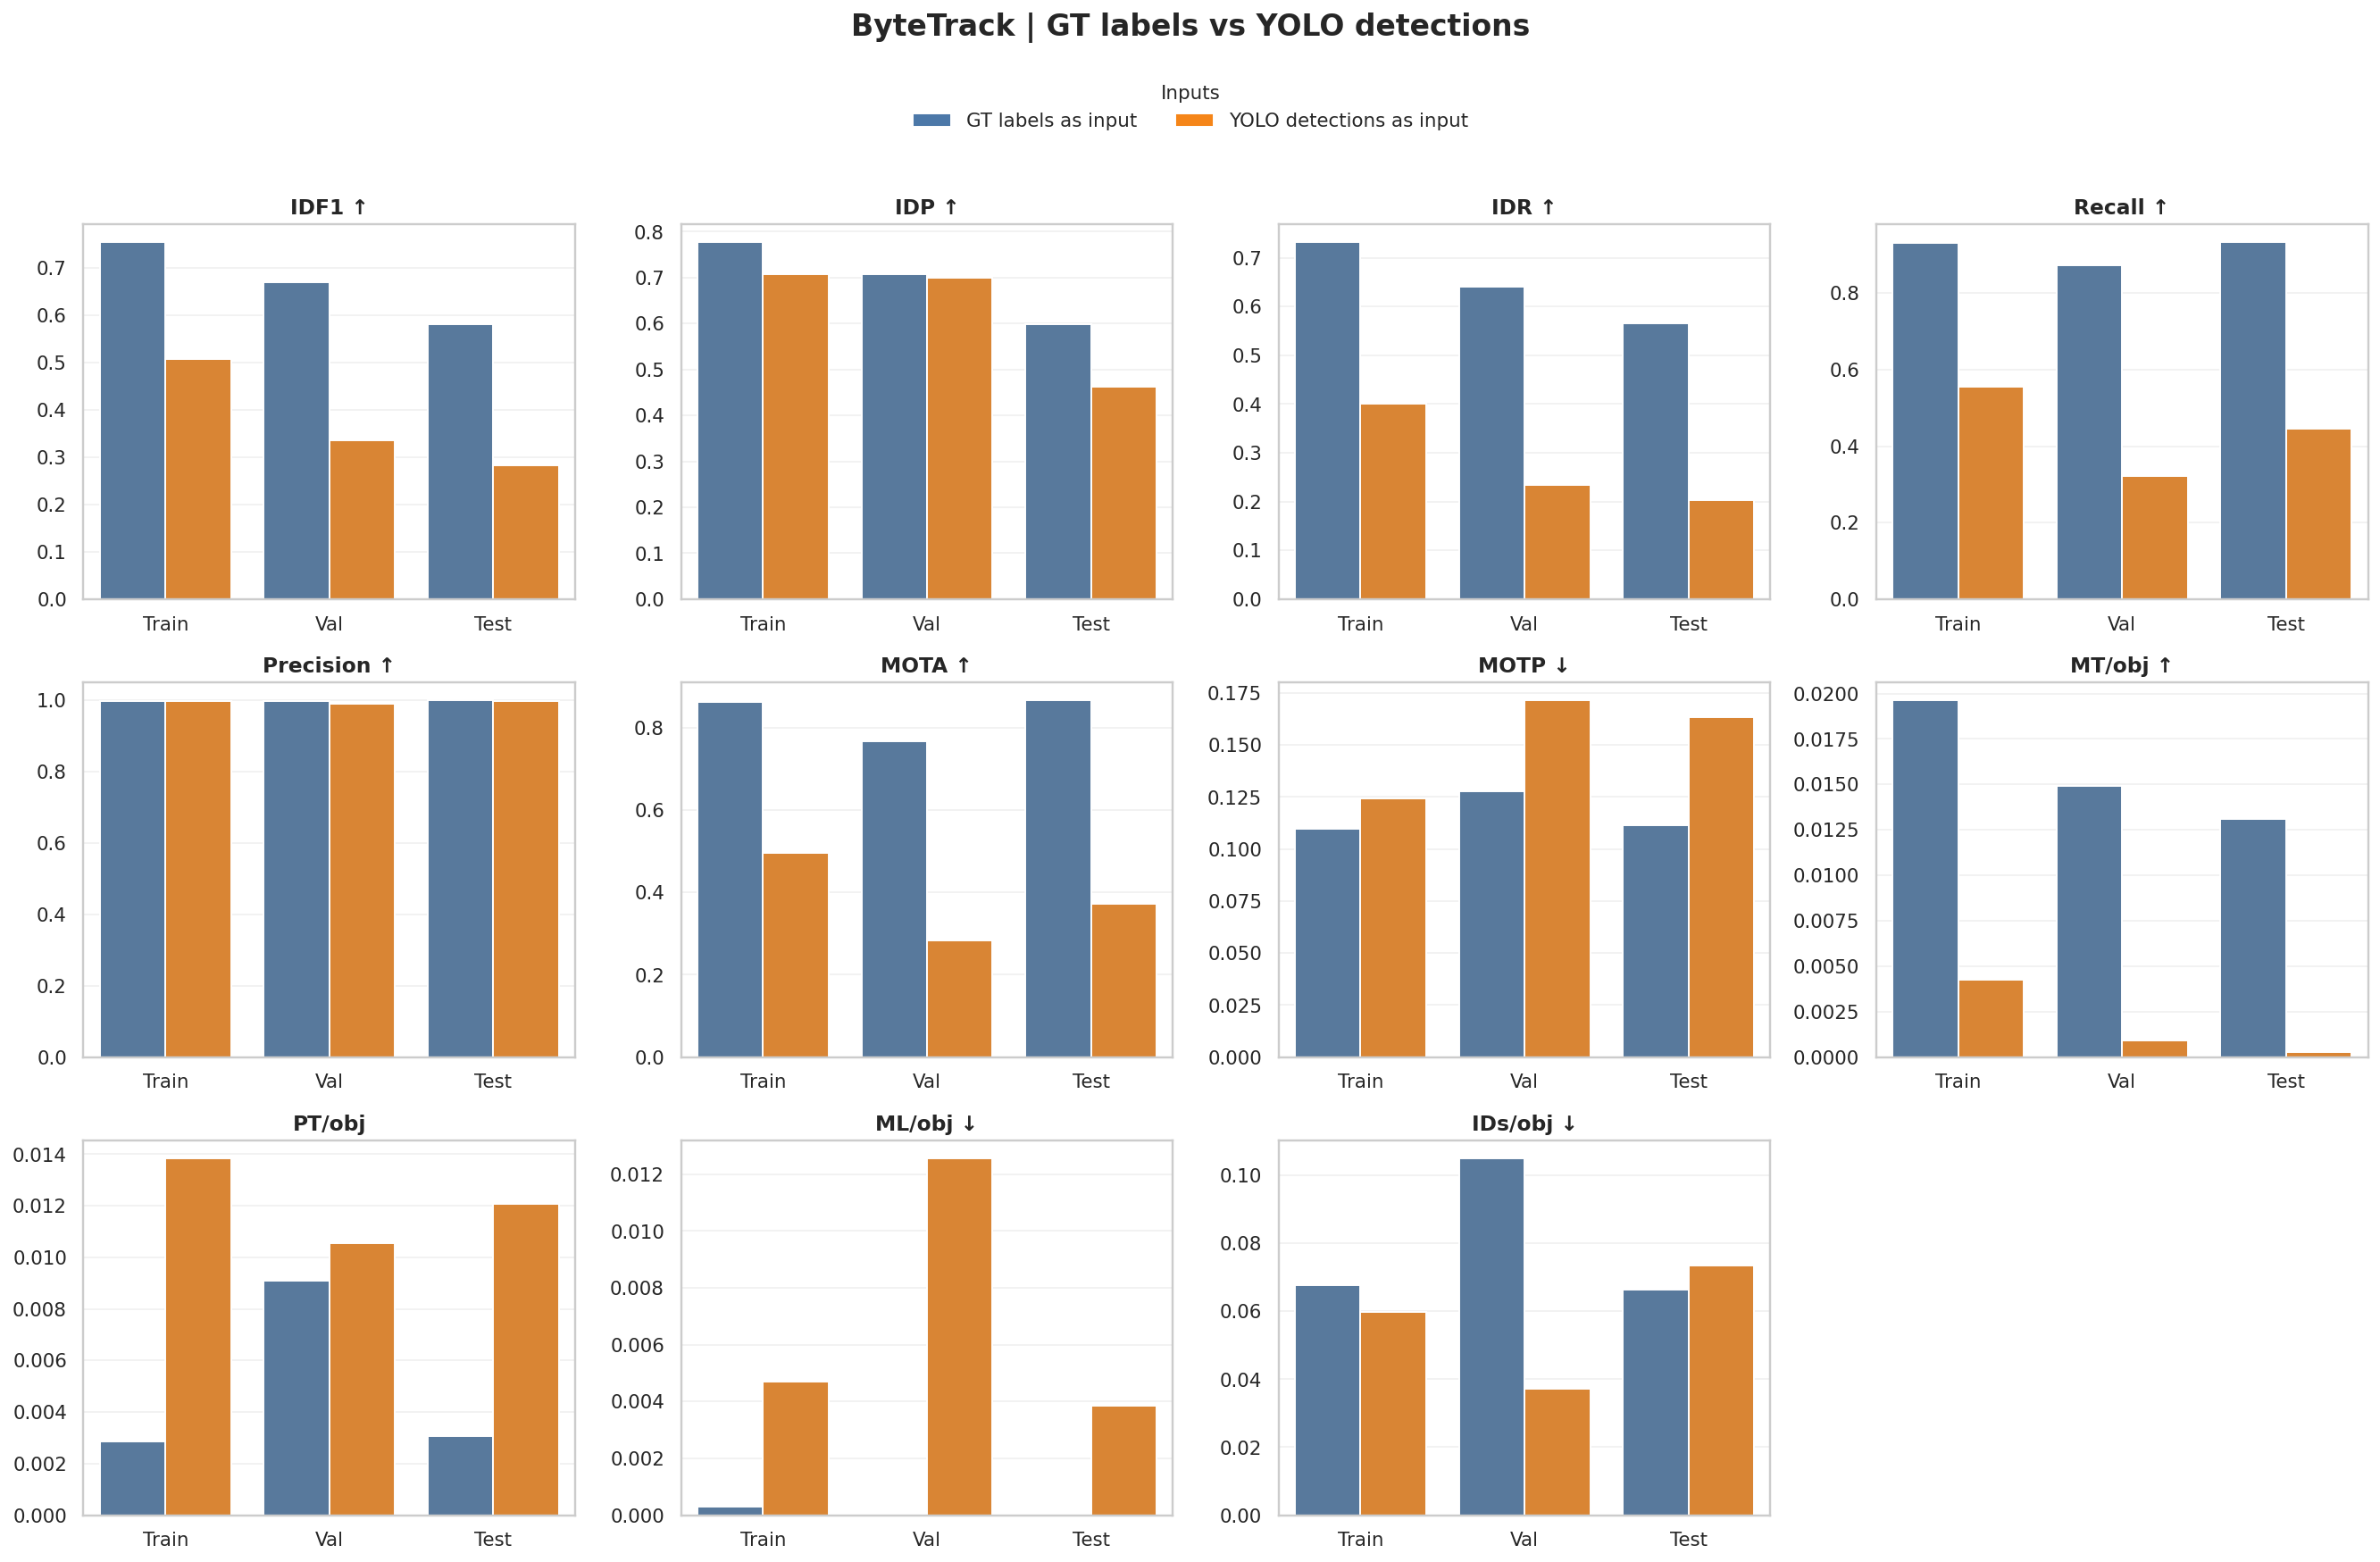

✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_botsort_gt_vs_yolo_metrics.png
✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_botsort_gt_vs_yolo_metrics.pdf


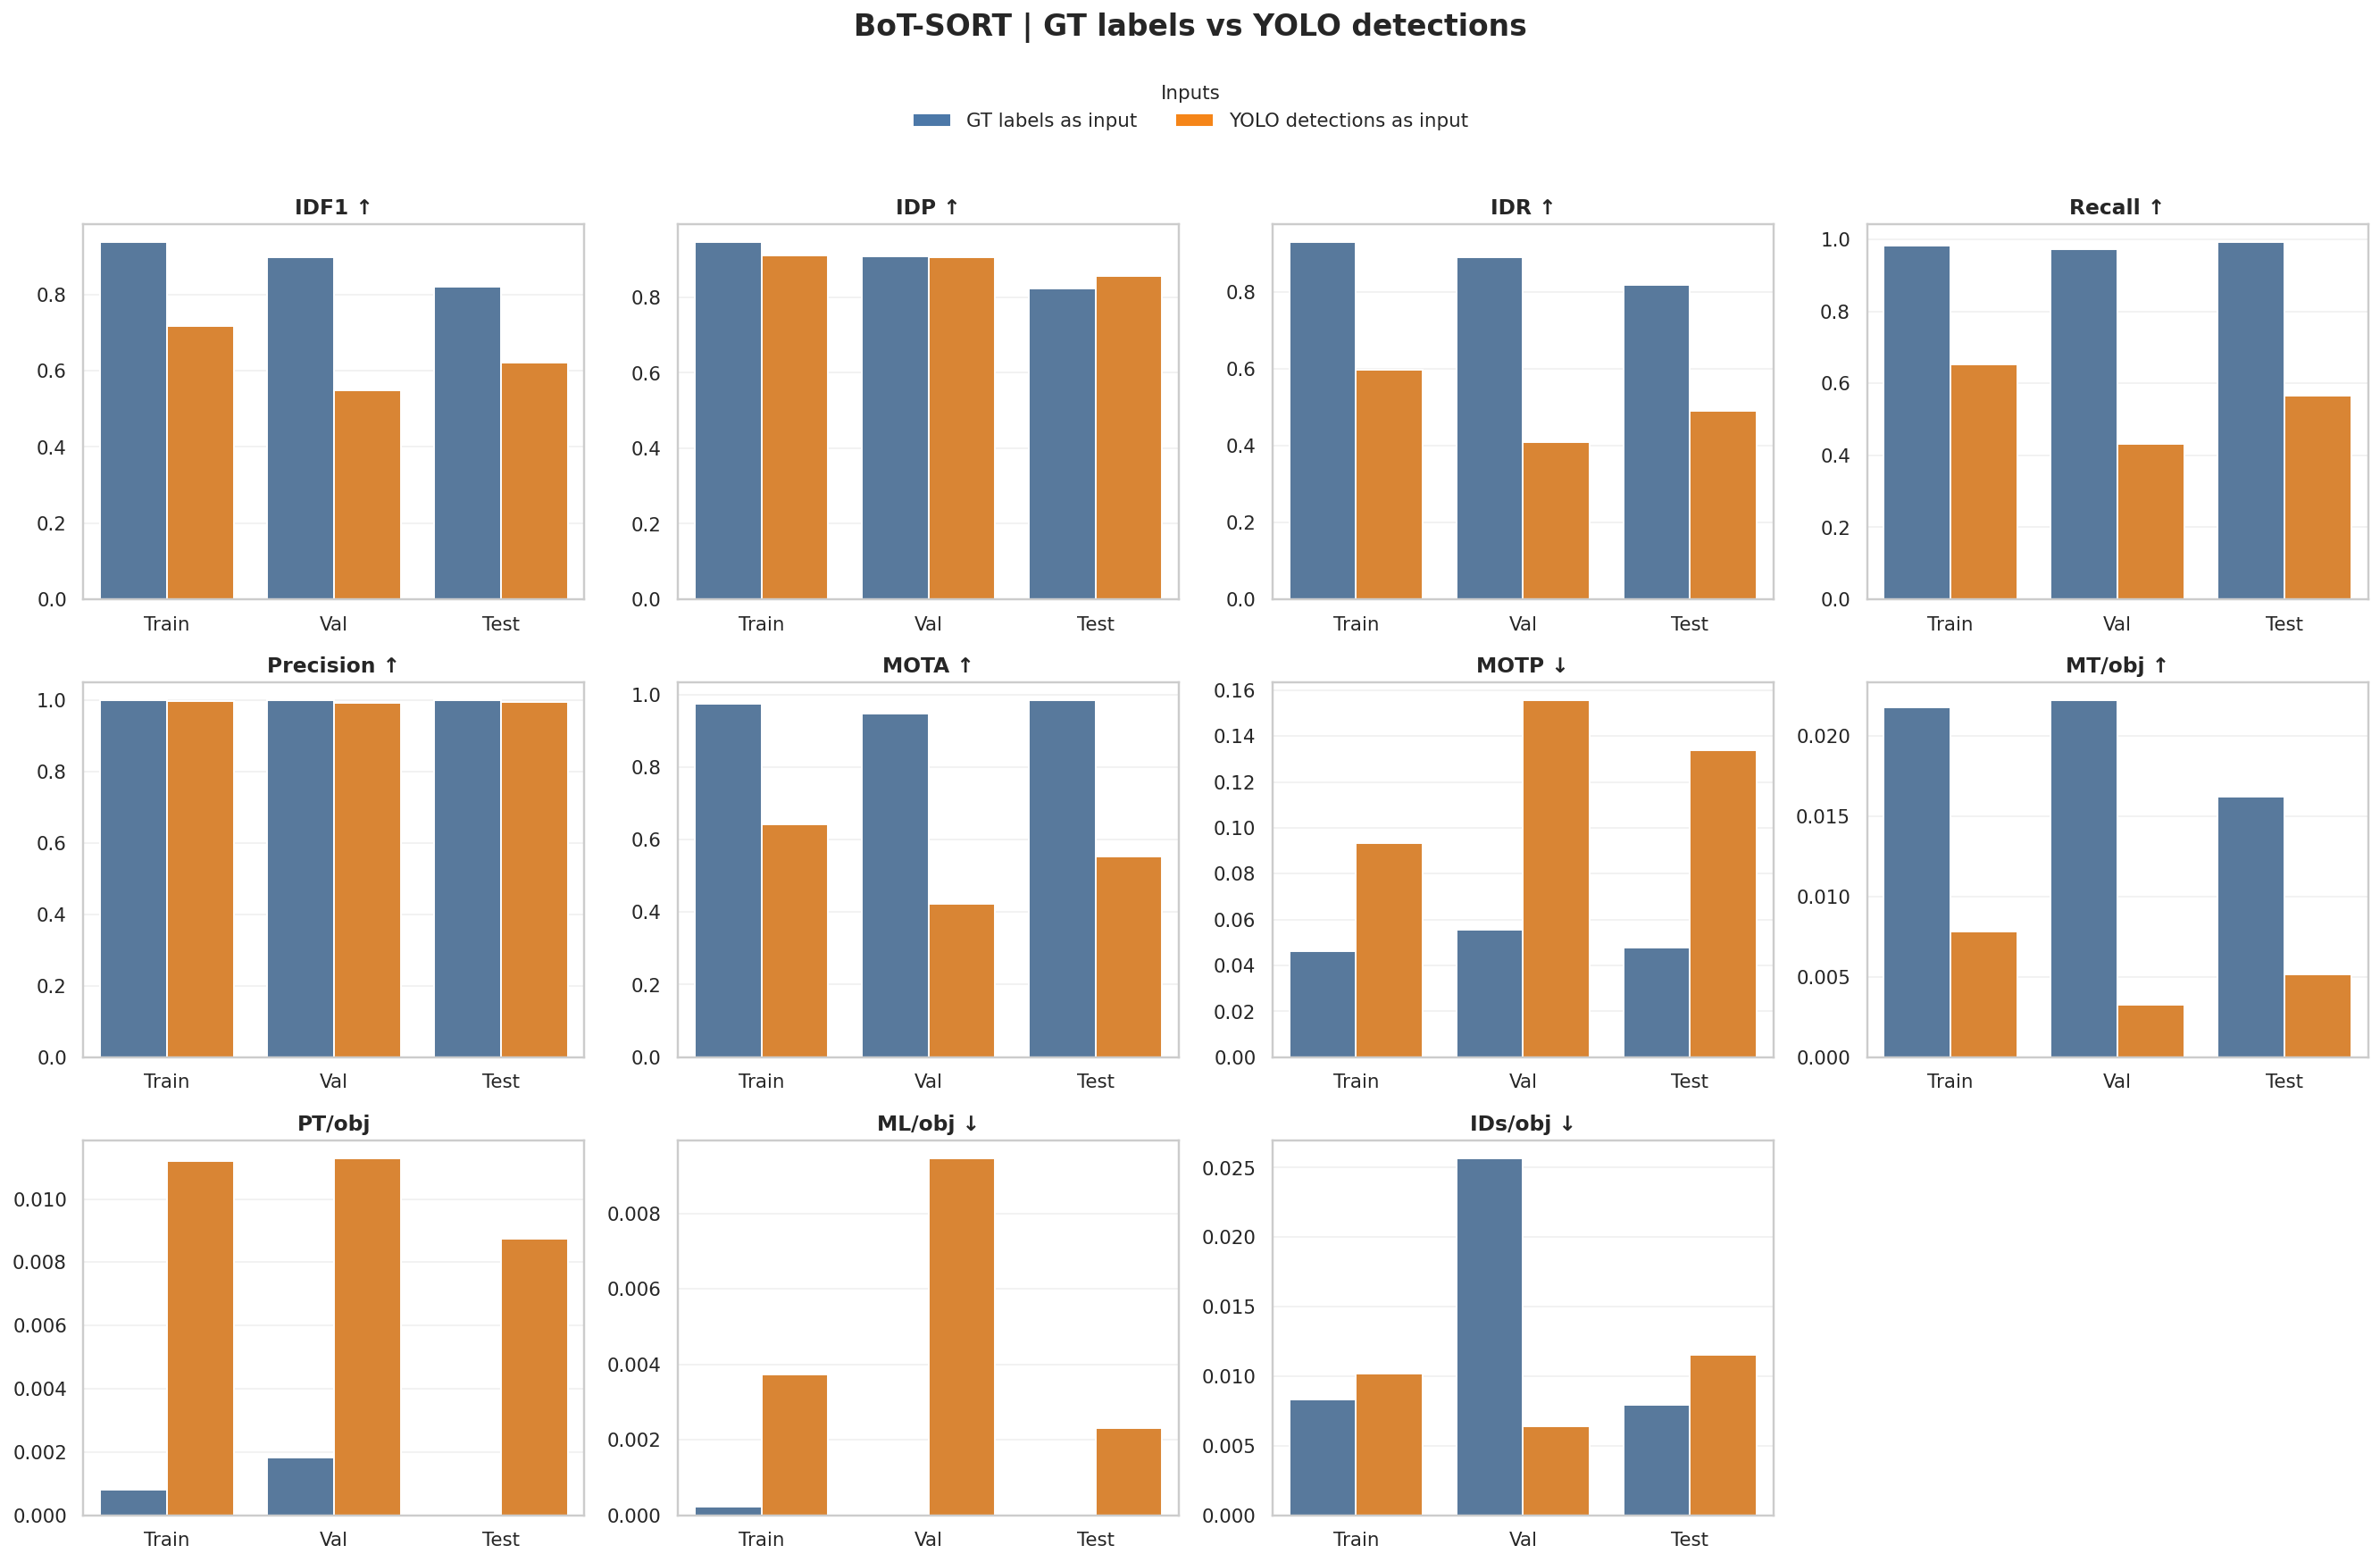

In [339]:
for tracker in TRACKER_RUNS:
    plot_gt_vs_yolo_grid_for_tracker(
        summary_df=summary_split,
        tracker=tracker,
        metric_labels=PLOT_METRICS_COMMON,
        max_cols=4,
        save_name=f"tracking_{tracker}_gt_vs_yolo_metrics",
    )

# Comparación final en test usando detecciones YOLO

Esta comparación corresponde al escenario más realista: el detector YOLO genera las detecciones y el tracker asigna las identidades a lo largo de la secuencia 

In [345]:
final_test_model = summary_split[
    (summary_split["split"] == "test")
    & (summary_split["source"] == "model_detections")
].copy()

final_test_model = final_test_model.sort_values("tracker").reset_index(drop=True)

final_test_model["Tracker"] = final_test_model["tracker"].map(TRACKER_NAMES)

final_test_model = format_metric_columns(final_test_model)

final_cols = [
    "Tracker",
    "Frames",
    "Objects",
    "IDF1 ↑",
    "IDP ↑",
    "IDR ↑",
    "Recall ↑",
    "Precision ↑",
    "MOTA ↑",
    "MOTP ↓",
    "MT/obj ↑",
    "PT/obj",
    "ML/obj ↓",
    "FP/obj ↓",
    "FN/obj ↓",
    "IDs/obj ↓",
    "FM/obj ↓",
]

final_cols = [
    col for col in final_cols
    if col in final_test_model.columns
]

final_compact = final_test_model[final_cols].copy()

display(final_compact.style.format(
    precision=4,
    na_rep="-"
))

,Tracker,Frames,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT/obj ↑,PT/obj,ML/obj ↓,FP/obj ↓,FN/obj ↓,IDs/obj ↓,FM/obj ↓
0,BoT-SORT,372,3892,0.6207,0.8559,0.4908,0.5671,0.9961,0.5534,0.1340,0.0051,0.0087,0.0023,0.0021,0.4329,0.0116,0.0588
1,ByteTrack,372,3892,0.2826,0.4622,0.2038,0.4468,0.9971,0.3720,0.1636,0.0003,0.0121,0.0039,0.0013,0.5532,0.0735,0.0933


In [341]:
save_latex_table(
    df=final_compact,
    file_path=DOCS_LATEX_DIR / "tracking_final_test_yolo_comparison.tex",
    caption="Comparación final de ByteTrack y BoT-SORT en test usando detecciones YOLO.",
    label="tab:tracking_final_test_yolo_comparison",
    index=False,
)

✅ Tabla LaTeX guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex/tracking_final_test_yolo_comparison.tex


# Gráfica final ByteTrack vs BoT-SORT

Se representa gráficamente la comparación final entre ByteTrack y BoT-SORT en el conjunto de test usando detecciones YOLO como entrada al tracker.

In [342]:
FINAL_TRACKER_COLORS = {
    "ByteTrack": "#54A24B",
    "BoT-SORT": "#B279A2",
}


def plot_final_tracker_comparison_grid(
    final_df: pd.DataFrame,
    metric_labels: list,
    max_cols: int = 4,
    save_name: str = None,
) -> None:
    """
    Plots ByteTrack vs BoT-SORT comparison on test using YOLO detections.

    Args:
        final_df (pd.DataFrame): Final compact dataframe with one row per tracker.
        metric_labels (list): Metric labels to plot.
        max_cols (int): Maximum number of subplot columns.
        save_name (str): Optional filename stem to save the figure.

    Returns:
        None
    """
    available_metrics = [
        metric for metric in metric_labels
        if metric in final_df.columns
    ]

    if len(available_metrics) == 0:
        print("No available metrics to plot.")
        return

    plot_df = final_df.copy()

    n_metrics = len(available_metrics)
    n_cols = min(max_cols, n_metrics)
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.8 * n_cols, 4.2 * n_rows),
        dpi=140,
    )

    axes = np.asarray(axes).reshape(-1)

    for ax_idx, metric_label in enumerate(available_metrics):
        ax = axes[ax_idx]

        sns.barplot(
            data=plot_df,
            x="Tracker",
            y=metric_label,
            hue="Tracker",
            palette=FINAL_TRACKER_COLORS,
            dodge=False,
            ax=ax,
        )

        ax.set_title(metric_label, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(axis="y", alpha=0.25)

        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    for empty_ax in axes[n_metrics:]:
        empty_ax.axis("off")

    fig.suptitle(
        "Test | YOLO detections | ByteTrack vs BoT-SORT",
        fontsize=17,
        fontweight="bold",
        y=0.99,
    )

    legend_handles = [
        Patch(
            facecolor=FINAL_TRACKER_COLORS["ByteTrack"],
            label="ByteTrack",
        ),
        Patch(
            facecolor=FINAL_TRACKER_COLORS["BoT-SORT"],
            label="BoT-SORT",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=2,
        frameon=False,
        fontsize=11,
        title="Trackers",
        title_fontsize=11,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save_name is not None:
        save_current_figure(save_name)

    plt.show()

✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_final_test_yolo_tracker_comparison.png
✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_final_test_yolo_tracker_comparison.pdf


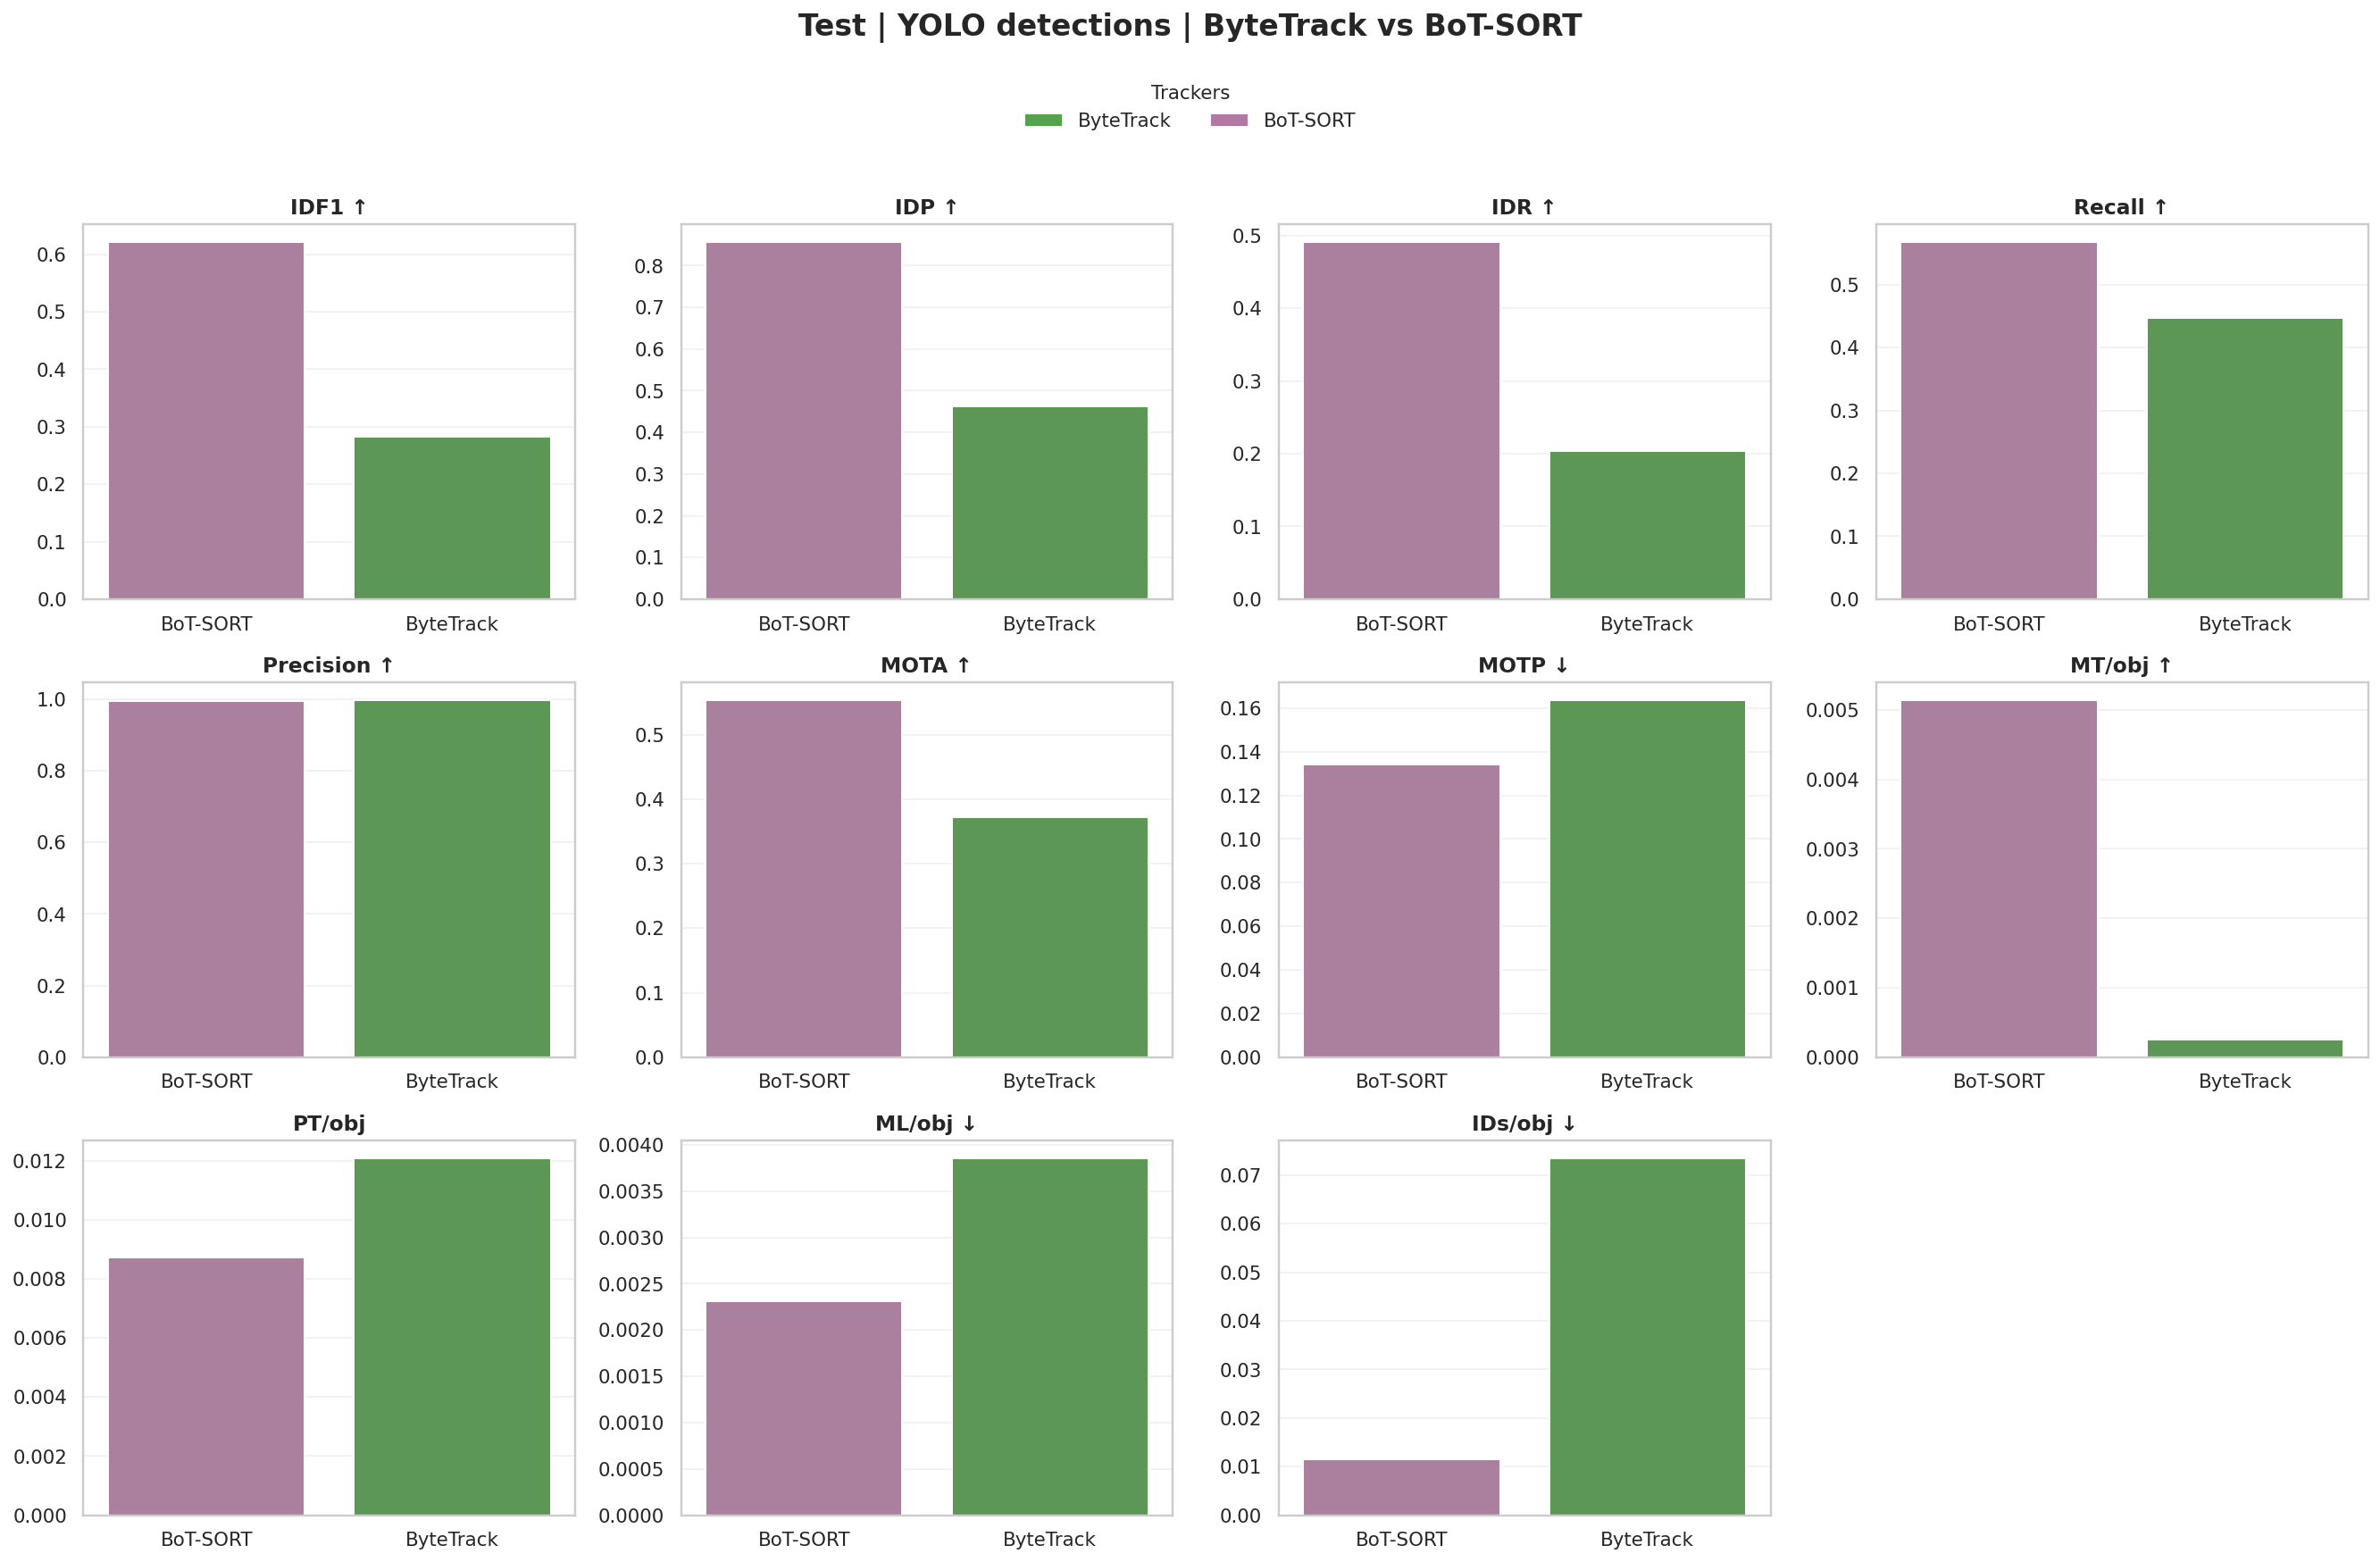

In [343]:
plot_final_tracker_comparison_grid(
    final_df=final_compact,
    metric_labels=FINAL_PLOT_METRICS,
    max_cols=4,
    save_name="tracking_final_test_yolo_tracker_comparison",
)

Y para comparar los tiempos de inferencia

In [344]:
time_yolo_global = weighted_time_summary_by_group(
    df=all_results[all_results["source"] == "model_detections"].copy(),
    group_cols=["tracker"],
)

time_yolo_global_display = time_yolo_global.copy()
time_yolo_global_display["Tracker"] = time_yolo_global_display["tracker"].map(TRACKER_NAMES)

time_yolo_global_display = time_yolo_global_display.drop(
    columns=["tracker", "num_sequences", "num_frames"],
    errors="ignore",
)

# FPS estimados del pipeline completo: detector + tracker
time_yolo_global_display["FPS estimados ↑"] = (
    1000.0 / time_yolo_global_display["Total/frame (ms) ↓"]
)

time_yolo_global_display = time_yolo_global_display[
    [
        "Tracker",
        "Detector/frame (ms) ↓",
        "Tracker/frame (ms) ↓",
        "Total/frame (ms) ↓",
        "FPS estimados ↑",
    ]
]

display(
    time_yolo_global_display.style.format(
        {
            "Detector/frame (ms) ↓": "{:.3f}",
            "Tracker/frame (ms) ↓": "{:.3f}",
            "Total/frame (ms) ↓": "{:.3f}",
            "FPS estimados ↑": "{:.2f}",
        },
        na_rep="-",
    )
)

save_latex_table(
    df=time_yolo_global_display,
    file_path=DOCS_LATEX_DIR / "tracking_timing_global_yolo.tex",
    caption="Comparación temporal global de ByteTrack y BoT-SORT usando detecciones YOLO.",
    label="tab:tracking_timing_global_yolo",
    index=False,
)

,Tracker,Detector/frame (ms) ↓,Tracker/frame (ms) ↓,Total/frame (ms) ↓,FPS estimados ↑
0,BoT-SORT,15.285,60.672,75.957,13.17
1,ByteTrack,19.674,1.113,20.787,48.11


✅ Tabla LaTeX guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex/tracking_timing_global_yolo.tex


# Comparación por etiqueta usando detecciones YOLO

Además de comparar los trackers de forma global, se analiza su comportamiento por tipo de objeto.
En este dataset, el nombre de cada secuencia sigue el formato:

- `horse_1`
- `penguin_2`
- `pig_3`

Por tanto, se extrae la etiqueta de clase a partir del prefijo del nombre de la secuencia.
Esta comparación se realiza únicamente usando detecciones YOLO como entrada al tracker, ya que
representa el escenario real del pipeline completo

In [321]:
def extract_class_from_sequence(sequence_name: str) -> str:
    """
    Extracts the class label from a sequence name.

    Expected format:
        class_name_sequence_id

    Examples:
        horse_1 -> horse
        penguin_2 -> penguin
        pig_3 -> pig

    Args:
        sequence_name (str): Sequence name.

    Returns:
        str: Extracted class label.
    """
    parts = str(sequence_name).split("_")

    if len(parts) <= 1:
        return str(sequence_name)

    return "_".join(parts[:-1])

In [322]:
model_detection_results = all_results[
    all_results["source"] == "model_detections"
].copy()

model_detection_results["class_label"] = model_detection_results["sequence"].apply(
    extract_class_from_sequence
)

display(
    model_detection_results[
        ["tracker", "split", "source", "sequence", "class_label", "num_objects", "idf1", "mota", "motp"]
    ]
    .head()
    .style.format(precision=3, na_rep="-")
)

,tracker,split,source,sequence,class_label,num_objects,idf1,mota,motp
9,bytetrack,fold_2_train,model_detections,horse_2,horse,1162,0.245,0.309,0.133
10,bytetrack,fold_2_train,model_detections,horse_3,horse,3179,0.402,0.411,0.136
11,bytetrack,fold_2_train,model_detections,horse_4,horse,743,0.444,0.529,0.111
12,bytetrack,fold_2_train,model_detections,penguin_2,penguin,1781,0.673,0.573,0.098
13,bytetrack,fold_2_train,model_detections,penguin_4,penguin,1246,0.527,0.421,0.100


In [323]:
summary_model_by_class = weighted_summary_by_group(
    df=model_detection_results,
    group_cols=["tracker", "split", "class_label"],
)

summary_model_by_class_display = summary_model_by_class.copy()

summary_model_by_class_display["Tracker"] = summary_model_by_class_display["tracker"].map(TRACKER_NAMES)
summary_model_by_class_display["Split"] = summary_model_by_class_display["split"].map(SPLIT_NAMES)
summary_model_by_class_display["Etiqueta"] = summary_model_by_class_display["class_label"]

summary_model_by_class_display = summary_model_by_class_display.drop(
    columns=["tracker", "split", "class_label"],
)

summary_model_by_class_display = format_metric_columns(summary_model_by_class_display)

ordered_cols_by_class = [
    "Tracker",
    "Split",
    "Etiqueta",
    "Frames",
    "Objects",
    "IDF1 ↑",
    "IDP ↑",
    "IDR ↑",
    "Recall ↑",
    "Precision ↑",
    "MOTA ↑",
    "MOTP ↓",
    "MT/obj ↑",
    "PT/obj",
    "ML/obj ↓",
    "FP/obj ↓",
    "FN/obj ↓",
    "IDs/obj ↓",
    "FM/obj ↓",
]

ordered_cols_by_class = [
    col for col in ordered_cols_by_class
    if col in summary_model_by_class_display.columns
]

summary_model_by_class_display = summary_model_by_class_display[ordered_cols_by_class]

display(
    summary_model_by_class_display.style.format(
        precision=3,
        na_rep="-"
    )
)

,Tracker,Split,Etiqueta,Objects,IDF1 ↑,IDP ↑,IDR ↑,Recall ↑,Precision ↑,MOTA ↑,MOTP ↓,MT/obj ↑,PT/obj,ML/obj ↓,FP/obj ↓,FN/obj ↓,IDs/obj ↓,FM/obj ↓
0,BoT-SORT,Train,horse,5084,0.692,0.884,0.569,0.643,0.999,0.626,0.094,0.006,0.014,0.004,0.000,0.357,0.016,0.065
1,BoT-SORT,Train,penguin,3776,0.655,0.923,0.512,0.551,0.999,0.543,0.094,0.005,0.009,0.006,0.001,0.449,0.008,0.033
2,BoT-SORT,Train,pig,4797,0.793,0.931,0.696,0.743,0.997,0.735,0.092,0.011,0.010,0.002,0.002,0.257,0.006,0.041
3,BoT-SORT,Val,horse,4007,0.650,0.952,0.496,0.519,0.997,0.512,0.161,0.004,0.014,0.007,0.001,0.481,0.006,0.074
4,BoT-SORT,Val,penguin,961,0.415,0.915,0.268,0.285,0.972,0.272,0.144,0.001,0.007,0.008,0.008,0.715,0.005,0.046
5,BoT-SORT,Val,pig,526,0.022,0.545,0.011,0.021,1.000,0.011,0.136,0.000,0.000,0.032,0.000,0.979,0.010,0.010
6,BoT-SORT,Test,horse,2014,0.588,0.822,0.457,0.555,0.997,0.544,0.111,0.002,0.007,0.000,0.001,0.445,0.009,0.068
7,BoT-SORT,Test,penguin,793,0.802,0.958,0.690,0.719,0.998,0.711,0.130,0.015,0.009,0.003,0.001,0.281,0.006,0.048
8,BoT-SORT,Test,pig,1085,0.550,0.845,0.407,0.478,0.992,0.455,0.179,0.004,0.012,0.006,0.004,0.522,0.019,0.051
9,ByteTrack,Train,horse,5084,0.372,0.553,0.281,0.502,0.998,0.405,0.132,0.002,0.017,0.006,0.001,0.498,0.096,0.103


In [324]:
save_latex_table(
    df=summary_model_by_class_display,
    file_path=DOCS_LATEX_DIR / "tracking_yolo_by_class_summary.tex",
    caption="Resumen ponderado por etiqueta usando detecciones YOLO como entrada al tracker.",
    label="tab:tracking_yolo_by_class_summary",
    index=False,
)

✅ Tabla LaTeX guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/latex/tracking_yolo_by_class_summary.tex


In [325]:
def plot_tracker_comparison_by_class_for_split(
    class_summary_df: pd.DataFrame,
    split: str,
    metric_labels: list,
    max_cols: int = 4,
    save_name: str = None,
) -> None:
    """
    Plots ByteTrack vs BoT-SORT grouped by class label for one split.

    This plot uses only YOLO detections as tracker input.

    Args:
        class_summary_df (pd.DataFrame): Summary dataframe generated by
            weighted_summary_by_group with columns tracker, split and class_label.
        split (str): Split name to plot. Example: 'fold_2_train', 'fold_2_val' or 'test'.
        metric_labels (list): Metric labels to plot.
        max_cols (int): Maximum number of subplot columns.
        save_name (str): Optional filename stem to save the figure.

    Returns:
        None
    """
    sub = class_summary_df[class_summary_df["split"] == split].copy()

    if sub.empty:
        print(f"No data available for split={split}")
        return

    sub["Tracker"] = sub["tracker"].map(TRACKER_NAMES)
    sub["Etiqueta"] = sub["class_label"]

    available_metrics = [
        metric for metric in metric_labels
        if metric in sub.columns
    ]

    if len(available_metrics) == 0:
        print(f"No available metrics for split={split}")
        return

    n_metrics = len(available_metrics)
    n_cols = min(max_cols, n_metrics)
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.0 * n_cols, 4.3 * n_rows),
        dpi=140,
    )

    axes = np.asarray(axes).reshape(-1)

    for ax_idx, metric_label in enumerate(available_metrics):
        ax = axes[ax_idx]

        sns.barplot(
            data=sub,
            x="Etiqueta",
            y=metric_label,
            hue="Tracker",
            palette=FINAL_TRACKER_COLORS,
            ax=ax,
        )

        ax.set_title(metric_label, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(axis="y", alpha=0.25)

        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    for empty_ax in axes[n_metrics:]:
        empty_ax.axis("off")

    split_title = SPLIT_NAMES.get(split, split)

    fig.suptitle(
        f"{split_title} | YOLO detections | Tracking metrics by class",
        fontsize=17,
        fontweight="bold",
        y=0.99,
    )

    legend_handles = [
        Patch(
            facecolor=FINAL_TRACKER_COLORS["ByteTrack"],
            label="ByteTrack",
        ),
        Patch(
            facecolor=FINAL_TRACKER_COLORS["BoT-SORT"],
            label="BoT-SORT",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=2,
        frameon=False,
        fontsize=11,
        title="Trackers",
        title_fontsize=11,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save_name is not None:
        save_current_figure(save_name)

    plt.show()

✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_yolo_by_class_train.png
✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_yolo_by_class_train.pdf


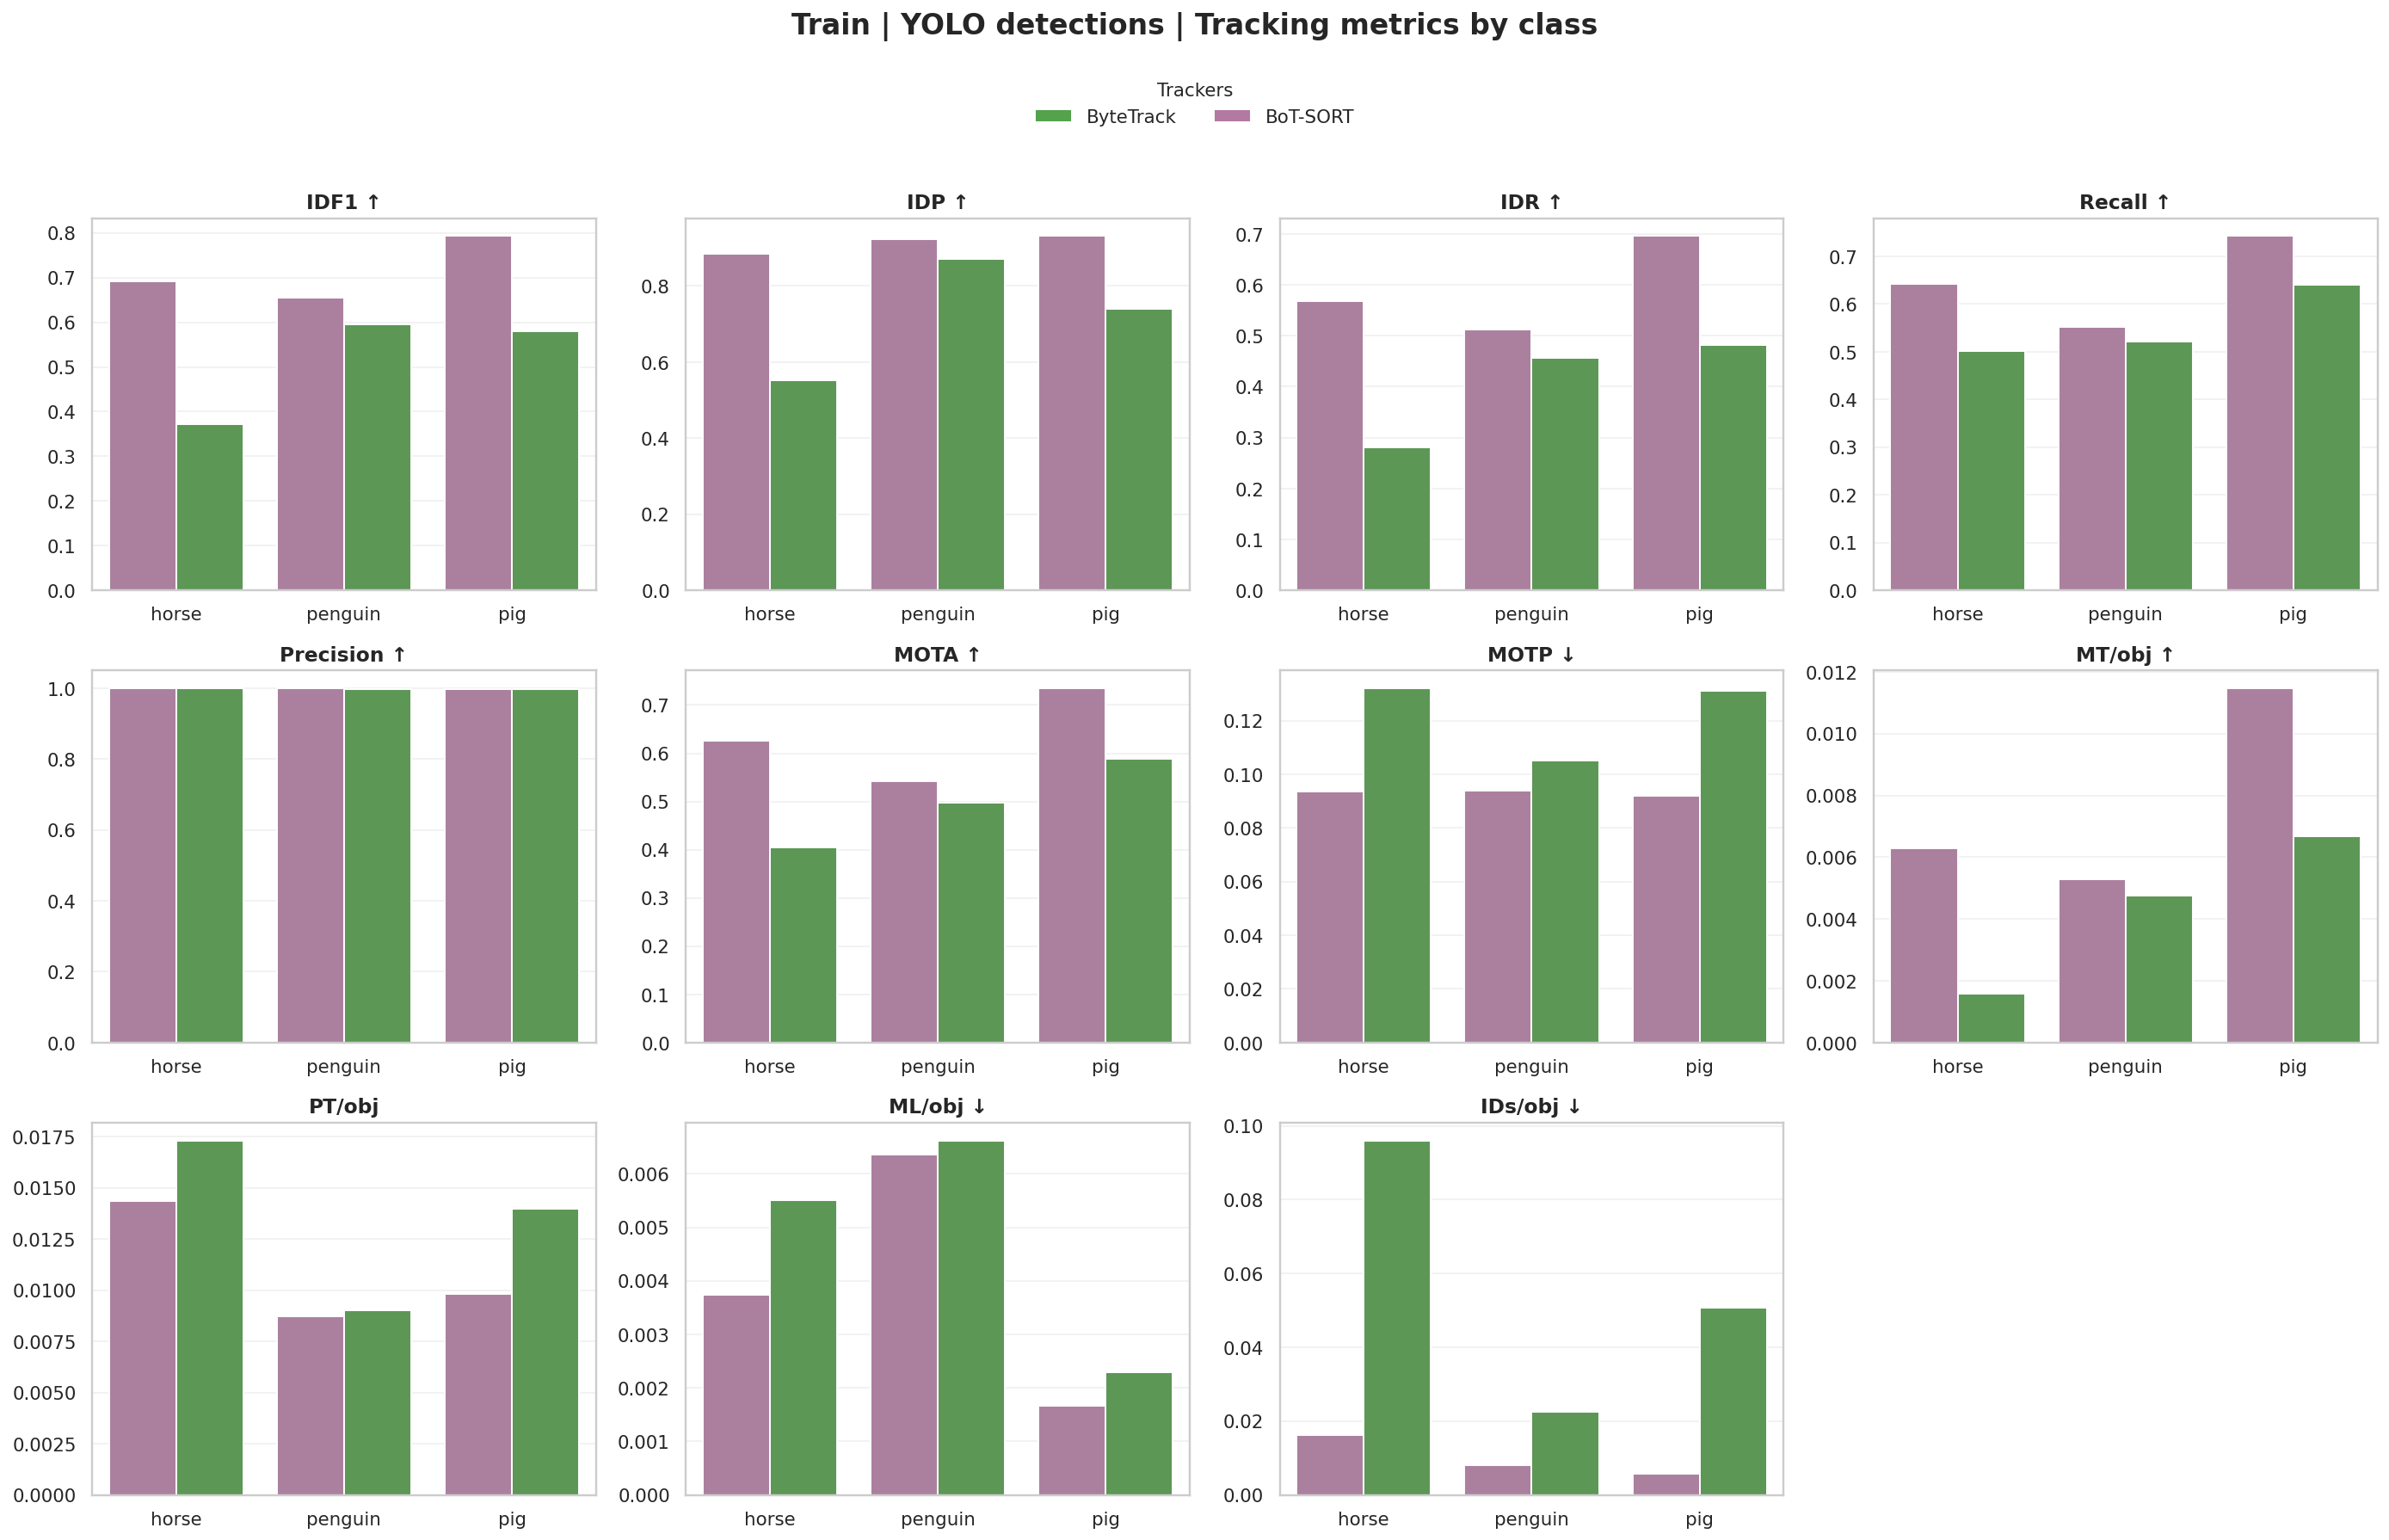

✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_yolo_by_class_val.png
✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_yolo_by_class_val.pdf


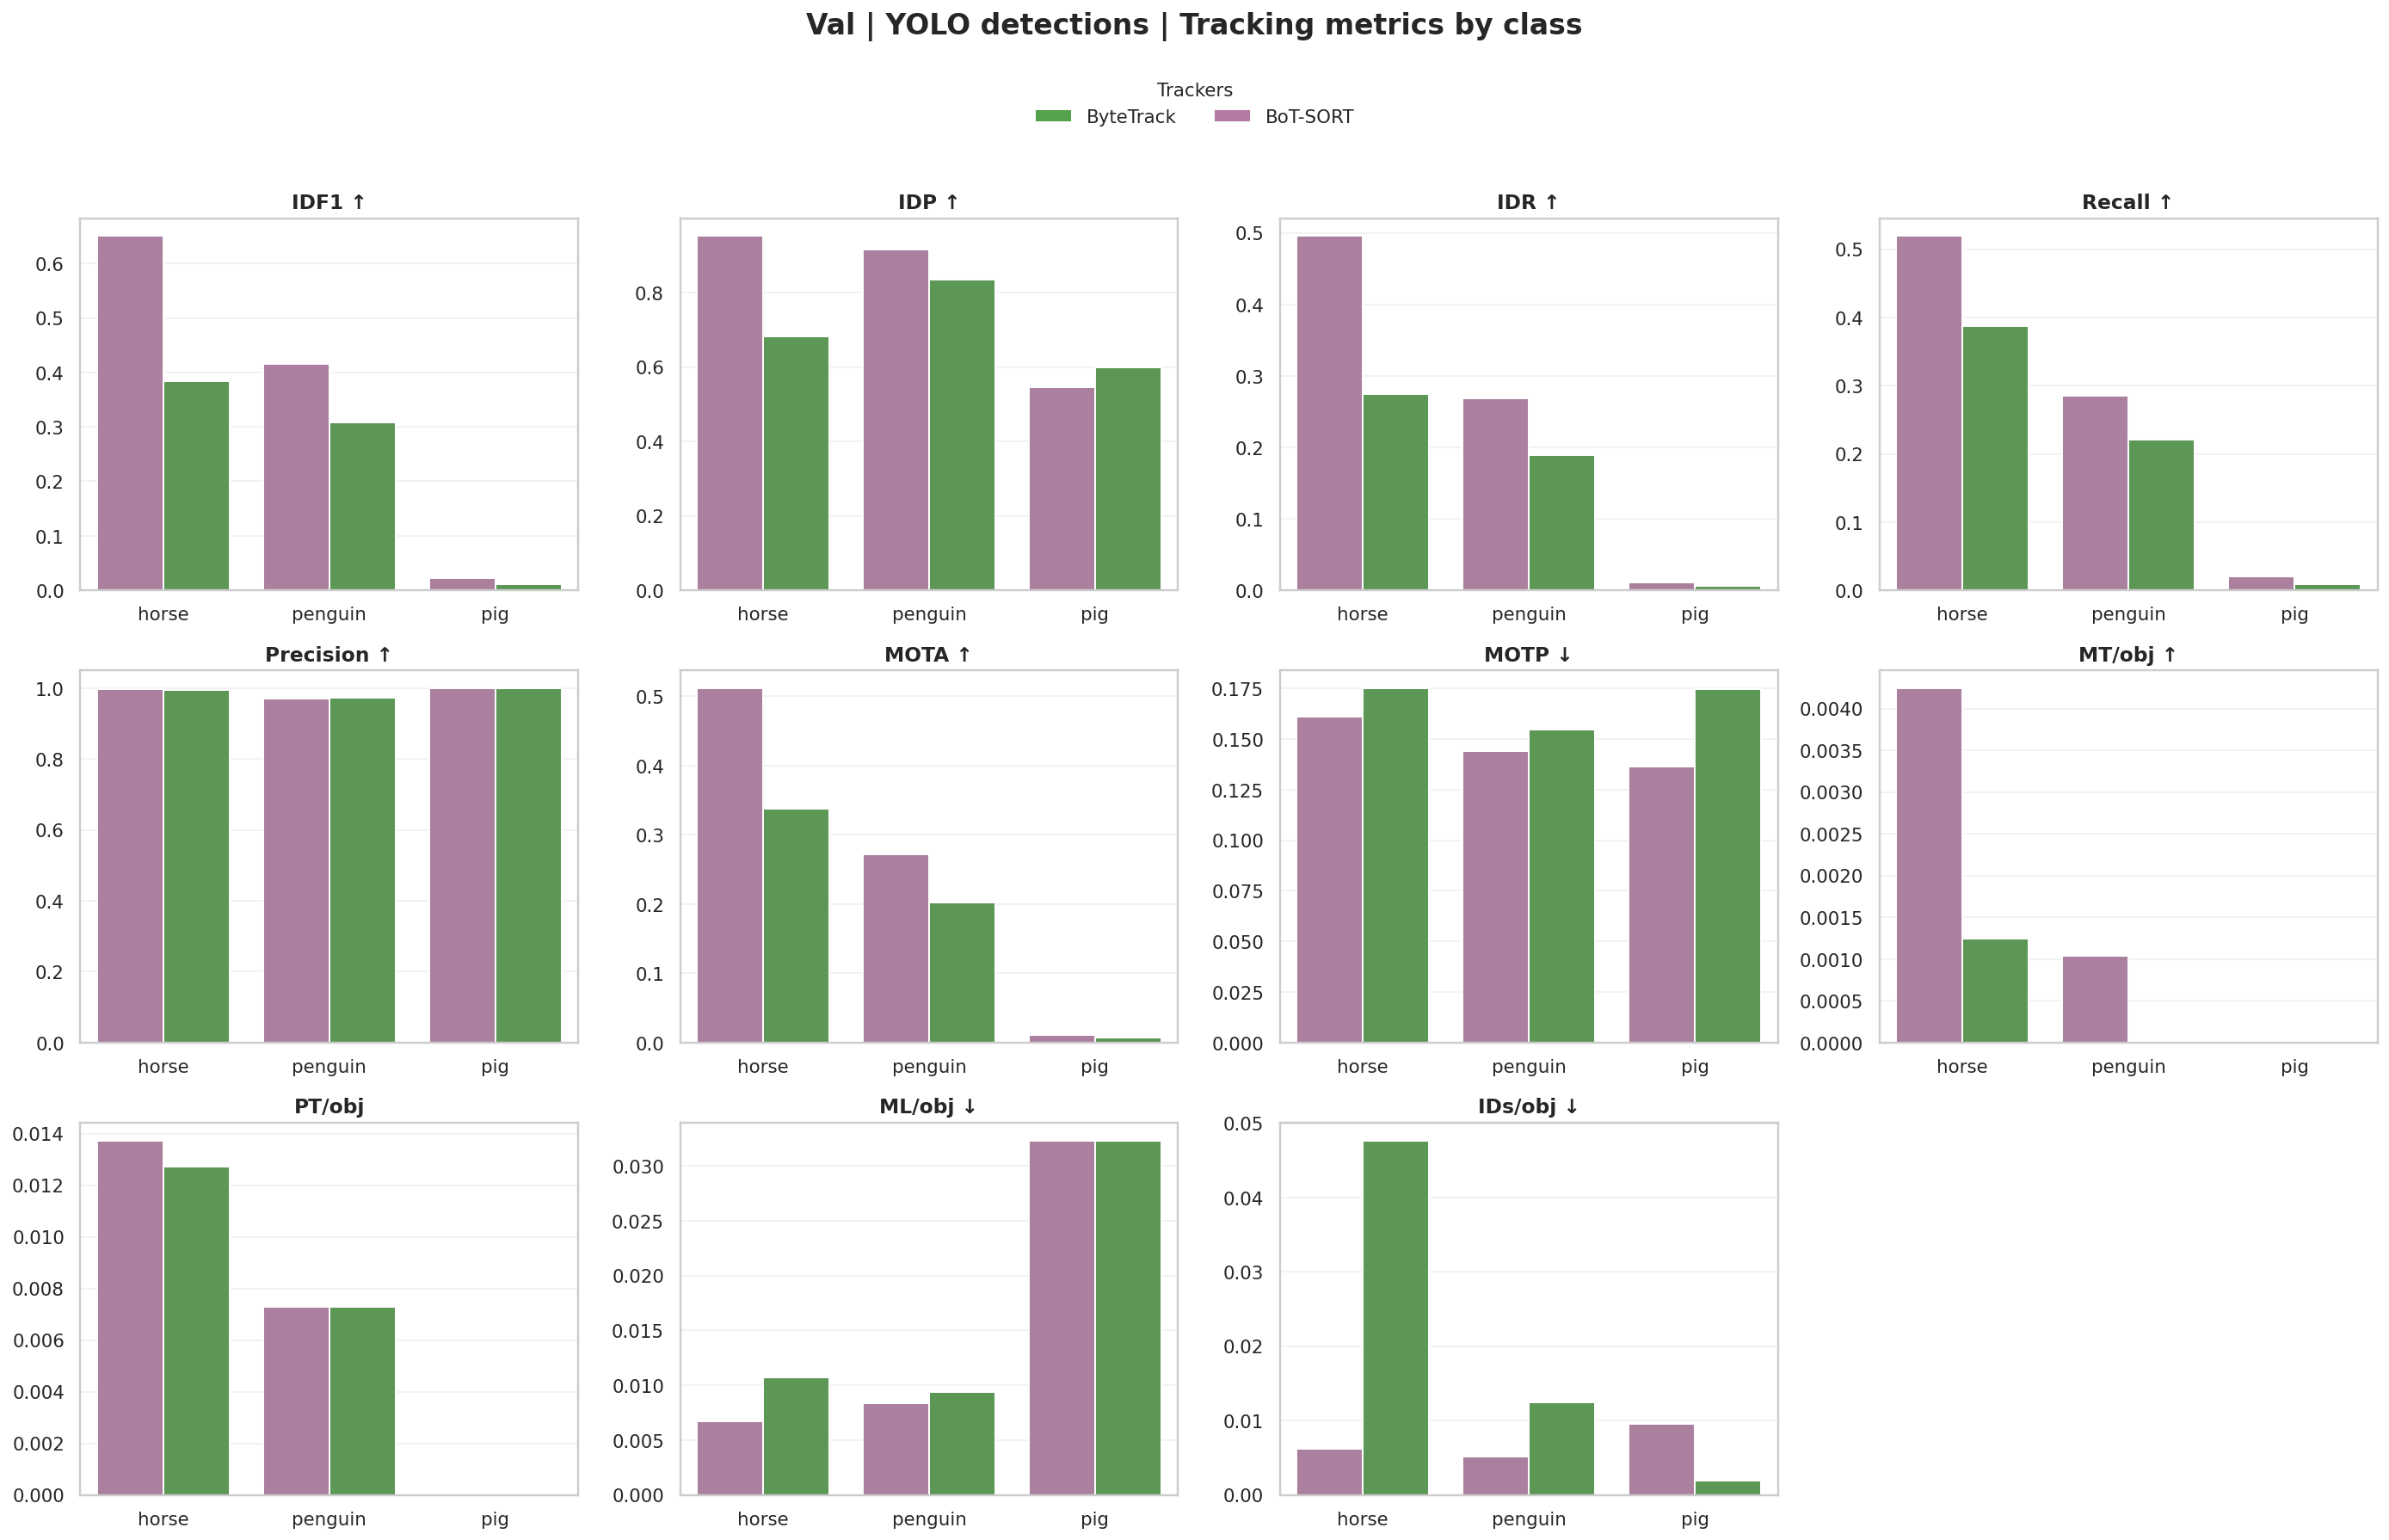

✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_yolo_by_class_test.png
✅ Figura guardada en: /home/cgonzalez/Object_Recognition/notebook_scripts/docs/images/tracking_yolo_by_class_test.pdf


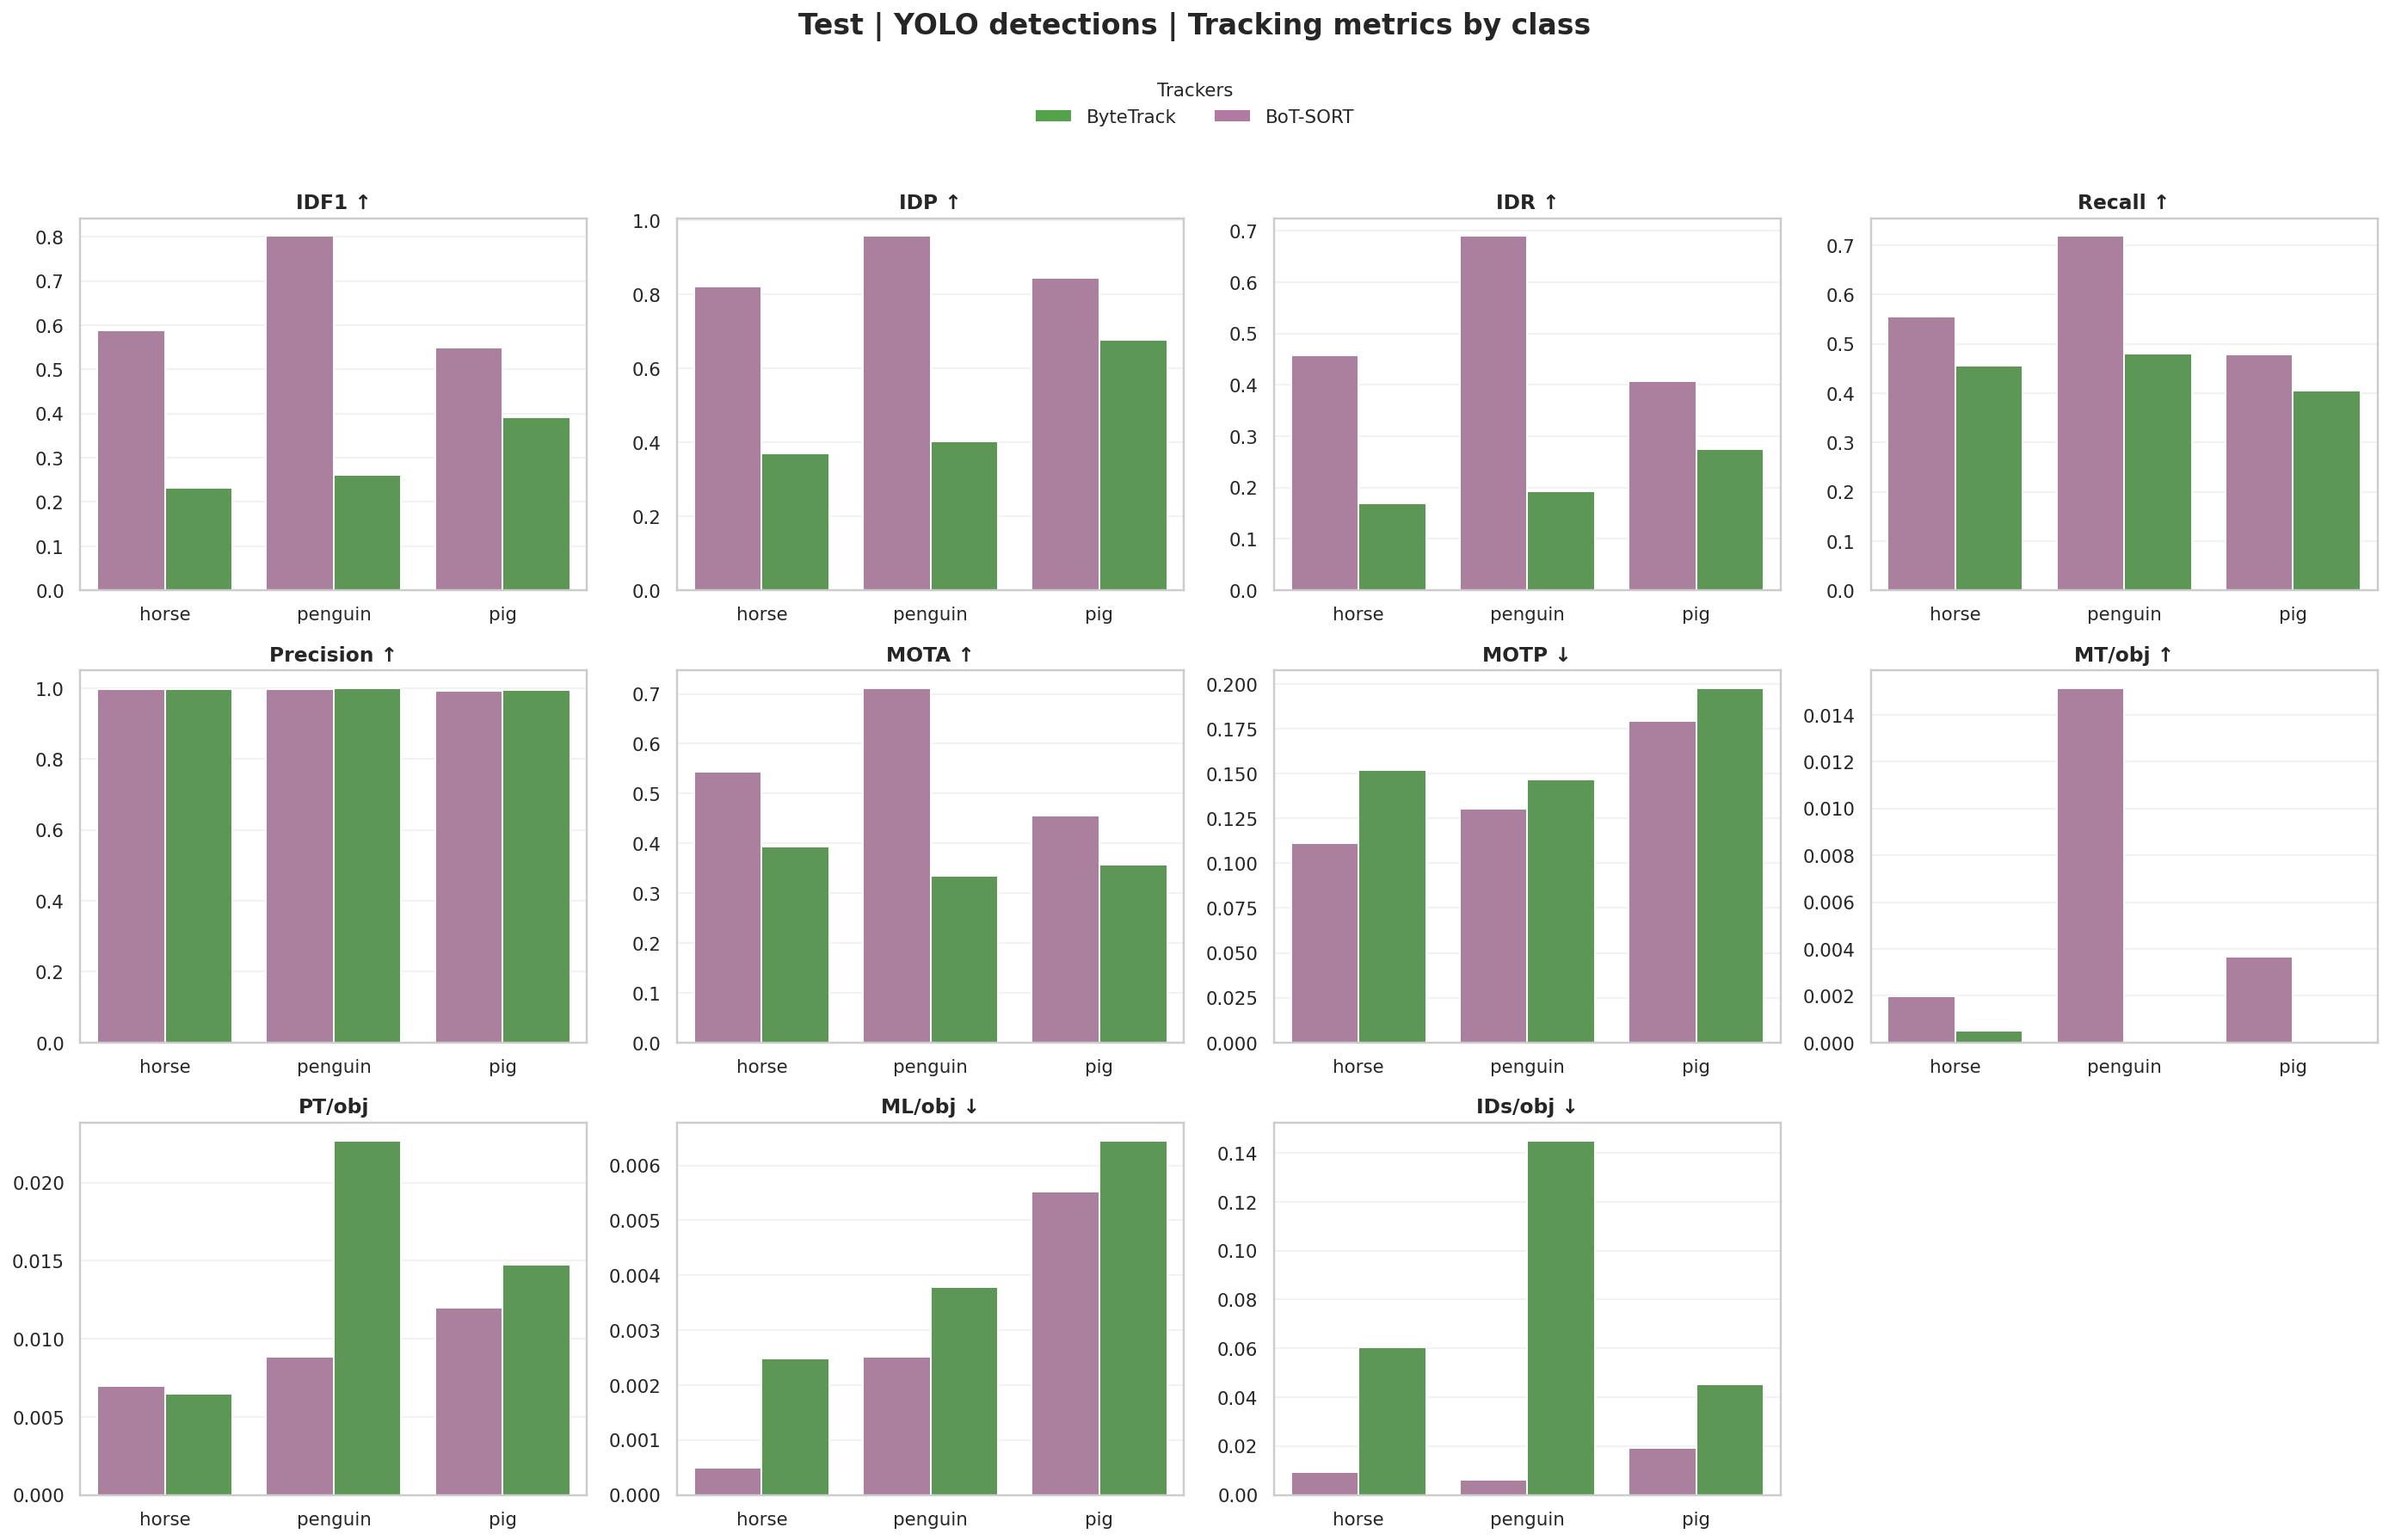

In [326]:
# %%
CLASS_PLOT_METRICS = [
    "IDF1 ↑",
    "Recall ↑",
    "Precision ↑",
    "MOTA ↑",
    "MOTP ↓",
    "IDs/obj ↓",
]

for split in SPLITS:
    split_name_for_file = SPLIT_NAMES.get(split, split).lower()

    plot_tracker_comparison_by_class_for_split(
        class_summary_df=summary_model_by_class,
        split=split,
        metric_labels=PLOT_METRICS_COMMON,
        max_cols=4,
        save_name=f"tracking_yolo_by_class_{split_name_for_file}",
    )